<a href="https://colab.research.google.com/github/alexrmziii/Python_Notebooks/blob/main/EasyVisa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EasyVisa Project

## Context:

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective:

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired your firm EasyVisa for data-driven solutions. You as a data scientist have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.


## Data Description

The data contains the different attributes of the employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Importing Necessary Libraries and Data

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 scikit-learn==1.2.2 matplotlib==3.7.1 seaborn==0.13.1 xgboost==2.0.3

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [ ]:
# libraries for data manipulation
import numpy as np
import pandas as pd

# libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# library for data splits
from sklearn.model_selection import train_test_split

# libraries for ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
)

from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# libraries for metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# library for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings("ignore")


In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## Importing Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# imports dataset
visa = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Datasets/EasyVisa.csv")
df = visa.copy()

## Data Overview

- Observations
- Sanity checks

### Data Observations

In [ ]:
# displays first five rows of the data
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [ ]:
# displays last five rows of the data
df.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


In [ ]:
# returns the dimensions of the data
df.shape

(25480, 12)

In [ ]:
# returns each column and its datatype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


### Sanity Checks

In [ ]:
# returns the sum of duplicate values
df.duplicated().sum()

0

There are no duplicate values to drop.

In [ ]:
# returns the sum of null values
df.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


There are no missing values to fix.

In [ ]:
# returns the sum of unique values for each object column
categorical = df.select_dtypes(include="object").columns.tolist()
print(df[categorical].nunique())

case_id                  25480
continent                    6
education_of_employee        4
has_job_experience           2
requires_job_training        2
region_of_employment         5
unit_of_wage                 4
full_time_position           2
case_status                  2
dtype: int64


In [ ]:
# drops case_id column
df.drop("case_id", axis=1, inplace=True)

In [ ]:
# displays the first five rows of the updated dataframe
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


Found and removed unique category case_id.

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**:
1. Those with higher education may want to travel abroad for a well-paid job. Does education play a role in Visa certification?

2. How does the visa status vary across different continents?

3. Experienced professionals might look abroad for opportunities to improve their lifestyles and career development. Does work experience influence visa status?

4. In the United States, employees are paid at different intervals. Which pay unit is most likely to be certified for a visa?

5. The US government has established a prevailing wage to protect local talent and foreign workers. How does the visa status change with the prevailing wage?

In [ ]:
# displays a statistical analysis of the data
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


Observations: Somehow, there is a negative number of employees.

In [ ]:
# displays an analysis of object data
df.describe(include='object')

,continent,education_of_employee,has_job_experience,requires_job_training,region_of_employment,unit_of_wage,full_time_position,case_status
count,25480,25480,25480,25480,25480,25480,25480,25480
unique,6,4,2,2,5,4,2,2
top,Asia,Bachelor's,Y,N,Northeast,Year,Y,Certified
freq,16861,10234,14802,22525,7195,22962,22773,17018


Observations: The most frequent values for each category are Asia, Bachelor's degree, has job experience, does not require job training, northeast region, yearly wage, has full time position, and certified case status.

In [ ]:
# fixes negative values in no_of_employees column
df["no_of_employees"]= np.abs(df["no_of_employees"])

### Custom Functions

In [ ]:
# used for univariate analysis to display distribution
def histogram_boxplot(data, feature, figsize=(20, 10), kde=False, bins=None):
  f2, (ax_box2, ax_hist2) = plt.subplots(
      nrows=2,  # two sublot rows
      sharex=True,  # shared x-axis
      gridspec_kw={"height_ratios": (0.25, 0.75)},
      figsize=figsize,
  )
  sns.boxplot(
      data=data,
      x=feature,
      ax=ax_box2,
      showmeans=True,
      color="#1f77b4"
  )
  sns.histplot(
      data=data,
      x=feature,
      kde=kde,
      color="#ff7f0e",
      ax=ax_hist2,
      bins=bins
  ) if bins else sns.histplot(
      data=data,
      x=feature,
      kde=kde,
      color="#ff7f0e",
      ax=ax_hist2
  )
  ax_hist2.axvline(
      data[feature].mean(), color="#e41a1c", linestyle="--", linewidth=2
  )
  ax_hist2.axvline(
      data[feature].median(), color="r", linestyle="-", linewidth=2
  )
  plt.show()

In [ ]:
# used for univariate analysis
def labeled_barplot(data, feature, perc=False, n=None):
    total = len(data[feature])
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )
        else:
            label = p.get_height()

        x = p.get_x() + p.get_width() / 2
        y = p.get_height()

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )
    plt.show()

In [ ]:
# used for multivariate analysis
def distribution_plot_wrt_target(data, predictor, target):
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    target_uniq = data[target].unique()
    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="#1f77b4",
        stat="density",
    )
    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="#ff7f0e",
        stat="density",
    )
    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="tab10")
    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="tab10",
    )
    plt.tight_layout()
    plt.show()

In [ ]:
# used for multivariate analysis
def stacked_barplot(data, predictor, target):
  count = data[predictor].nunique()
  sorter = data[target].value_counts().index[-1]
  tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
      by=sorter, ascending=False
  )
  print(tab1)
  print("-" * 120)
  tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
      by=sorter, ascending=False
  )
  tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
  plt.legend(loc="lower left", frameon=False)
  plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
  plt.ylabel(target)
  plt.show()

### Univariate Analysis

#### Continent

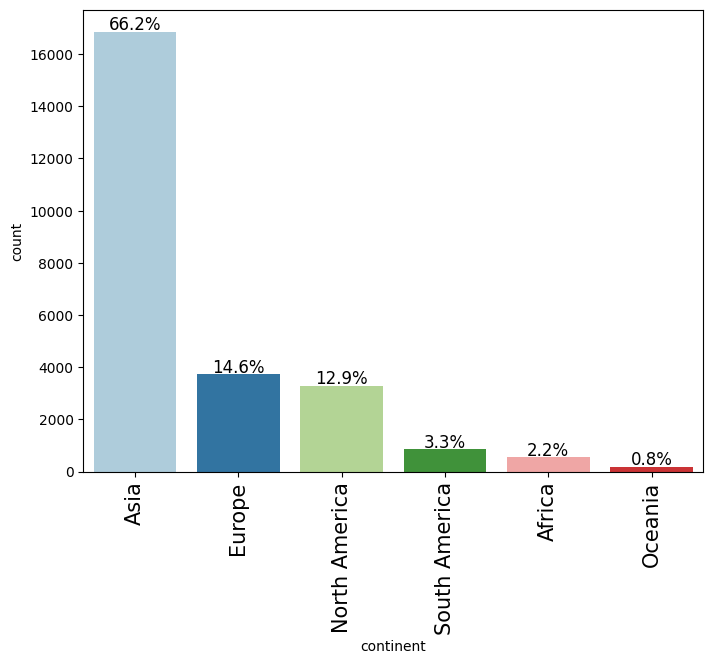

In [ ]:
labeled_barplot(df, "continent", perc=True)

Observations: The majority of applicants (66.2%) come from Asia. Europe (14.6%) and North America (12.9%) are the next largest demographics.

#### Education of Employee

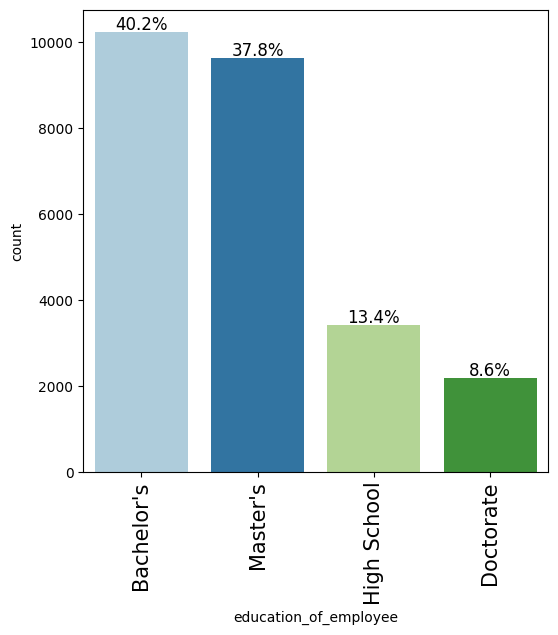

In [ ]:
labeled_barplot(df, "education_of_employee", perc=True)

Observations: The vast majority of applicants have either a Bachelor's (40.2%) or Master's degree (37.8%).

#### Job Experience

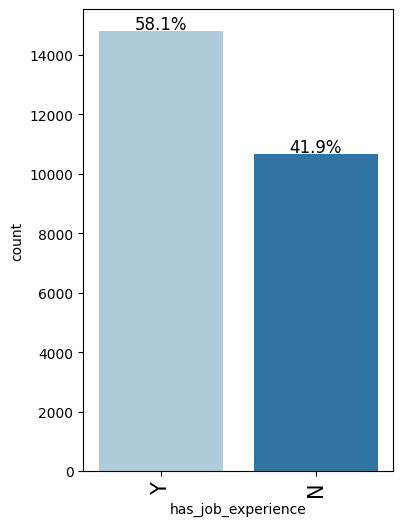

In [ ]:
labeled_barplot(df, "has_job_experience", perc=True)

Observations: 58.1% of applicants have job experience while 41.9% do not.

#### Job Training

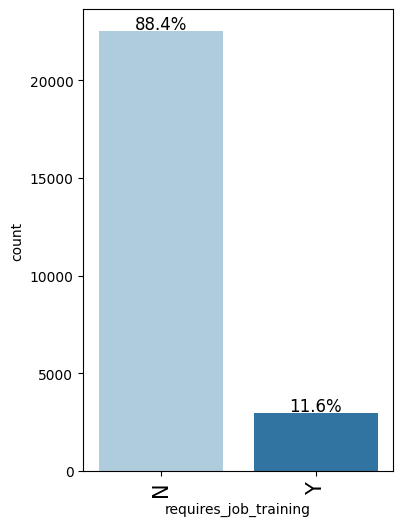

In [ ]:
labeled_barplot(df, "requires_job_training", perc=True)

Observations: The vast majority of applicants (88.4%) do not require job training.

#### Number of Employees

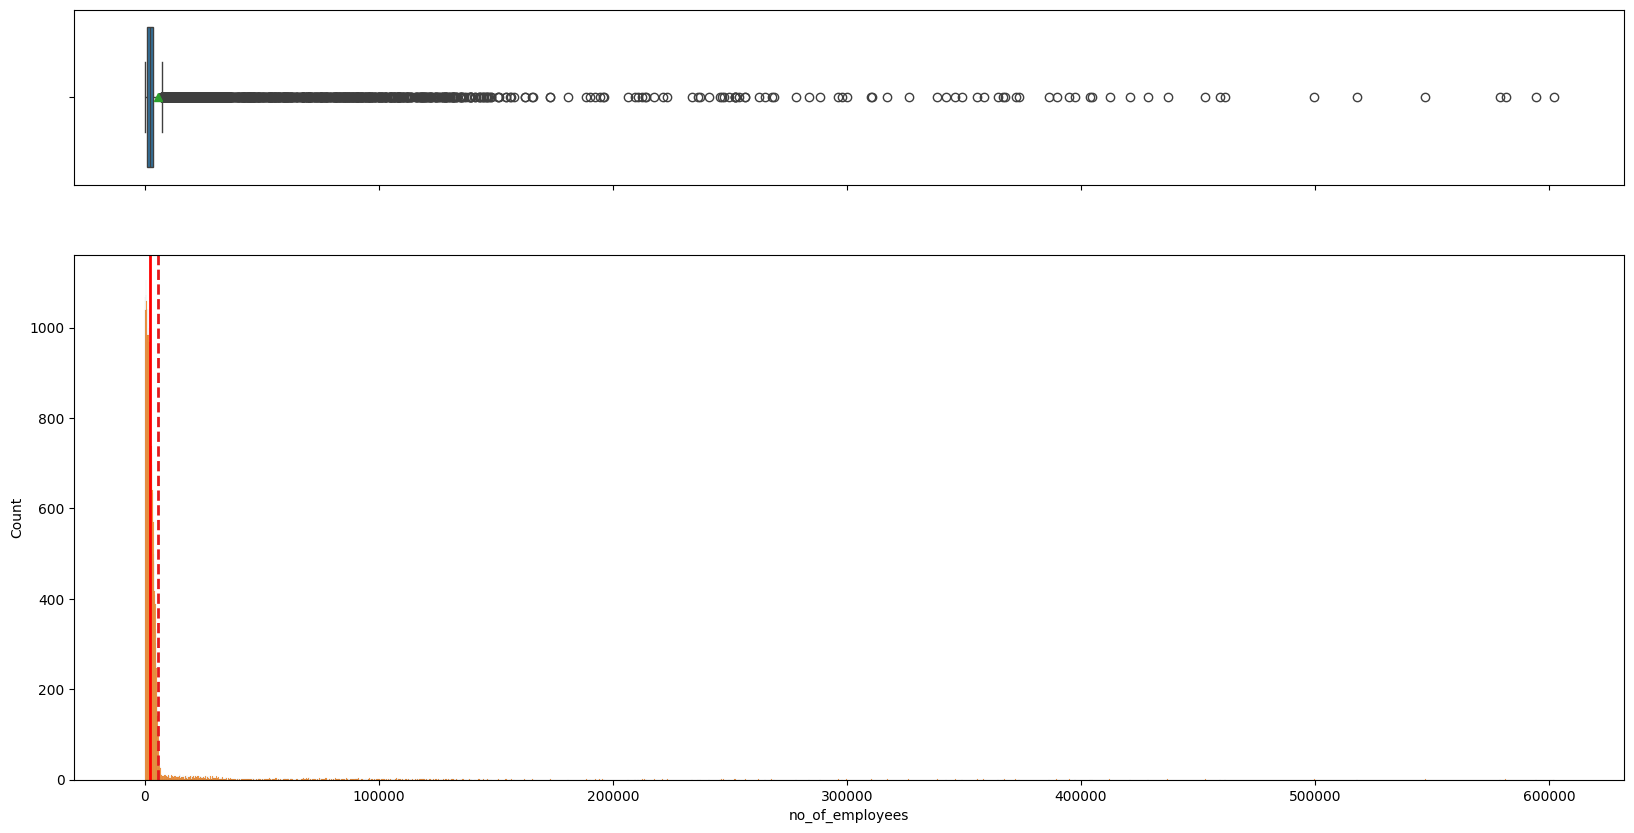

In [ ]:
histogram_boxplot(df, "no_of_employees")

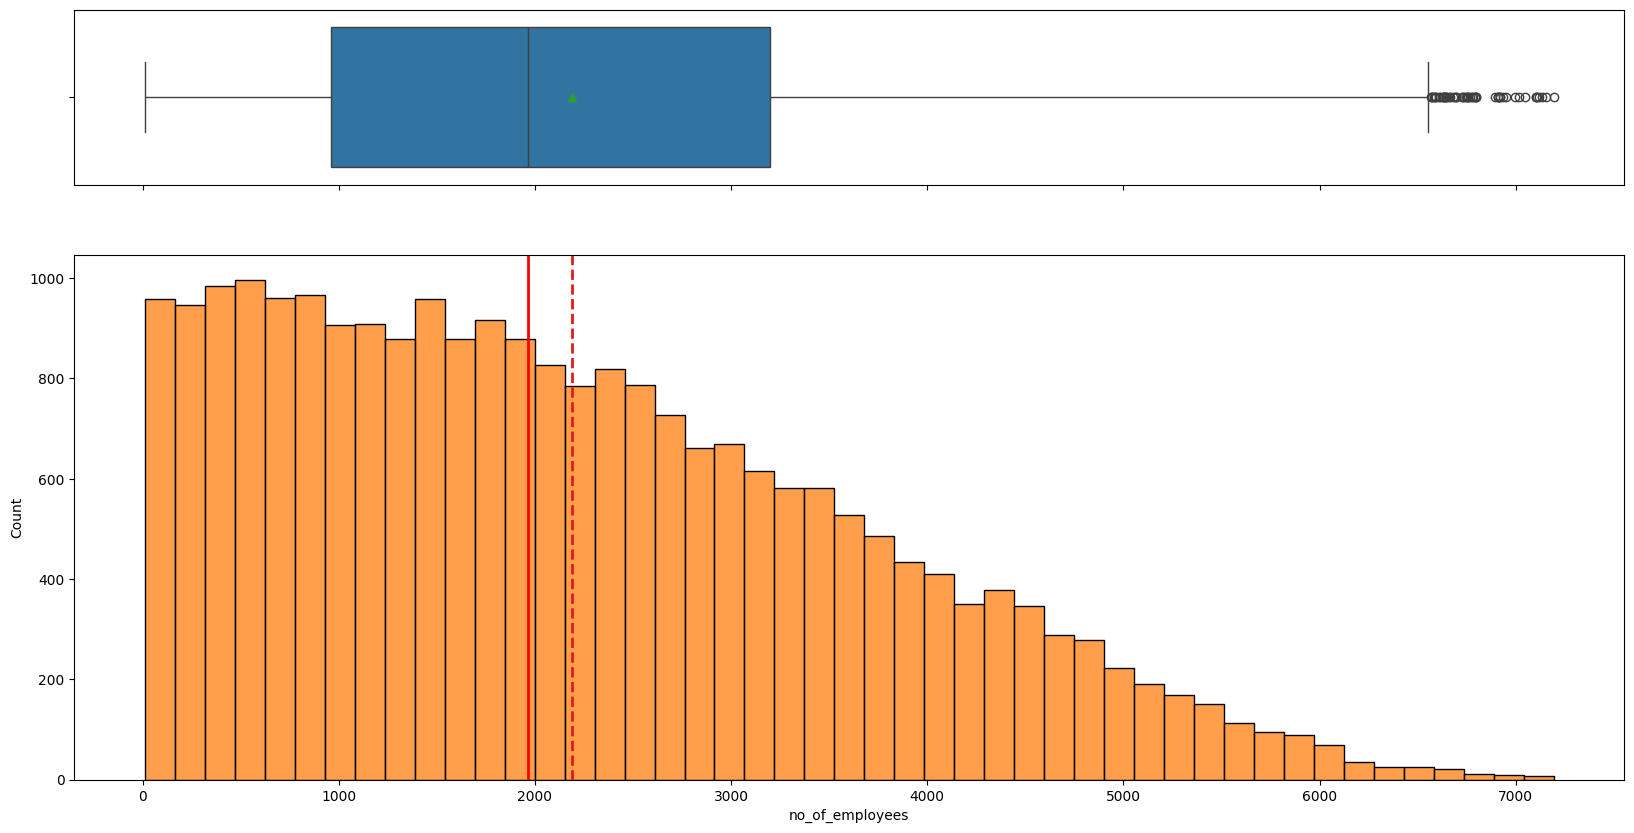

In [ ]:
employees = df["no_of_employees"]
Q1 = np.quantile(employees, 0.25)
Q3 = np.quantile(employees, 0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
df_no_outliers = df[(df["no_of_employees"] > lower_limit) & (df["no_of_employees"] < upper_limit)]

histogram_boxplot(df_no_outliers, "no_of_employees")

Observations: About 50% of the employers have between 1000 and ~3200 employees. The average number of employees is about 2200.

#### Year of Establishment

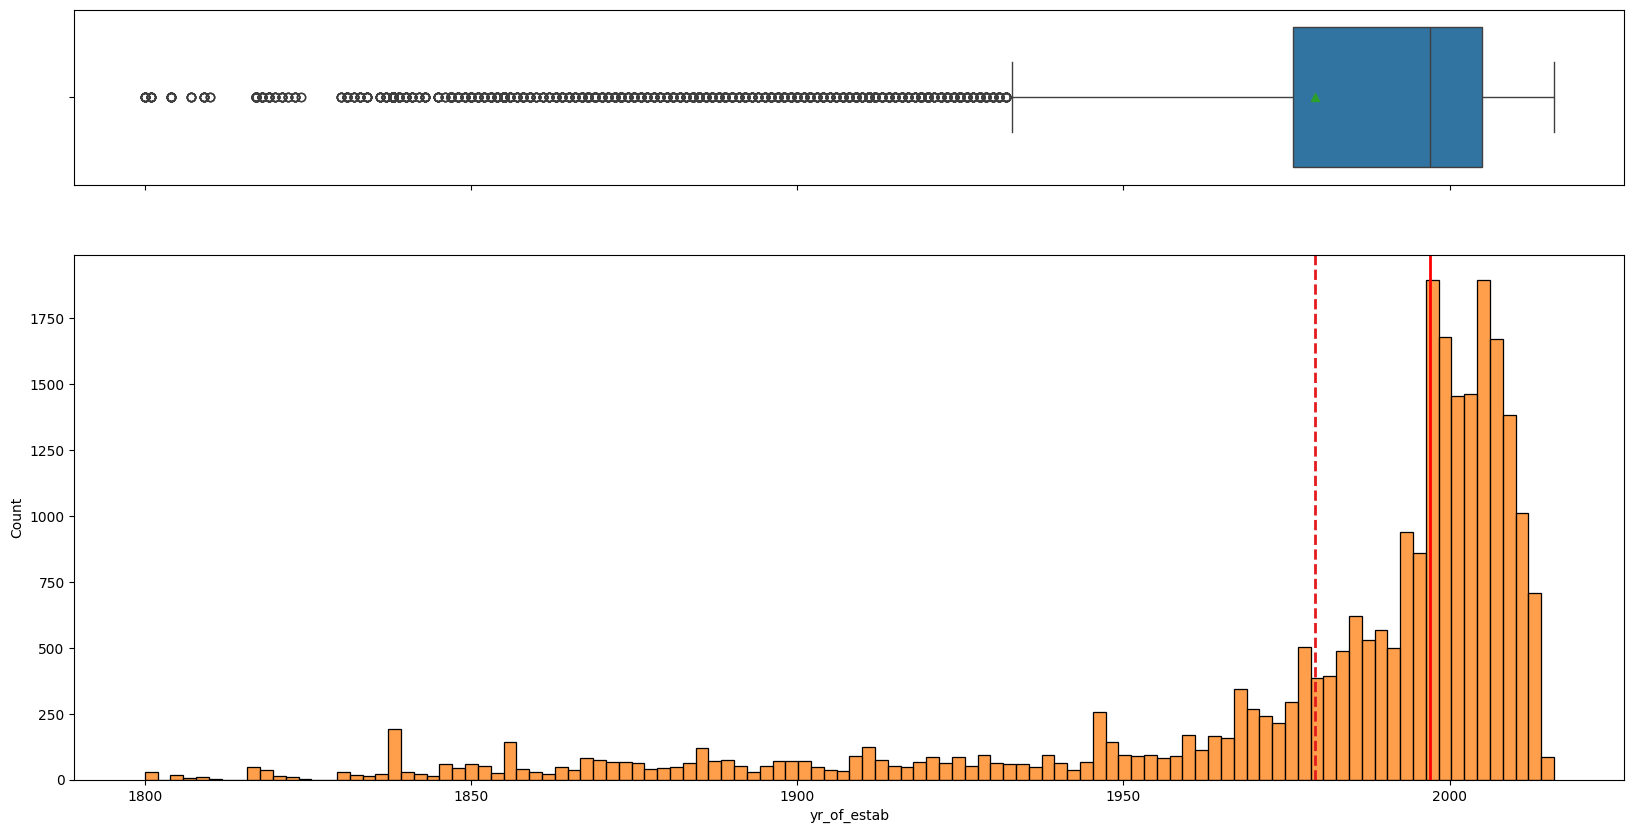

In [ ]:
histogram_boxplot(df, "yr_of_estab")

In [ ]:
np.mean(df["yr_of_estab"])

1979.409929356358

Observations: The average year the employer's company was established is 1979.

#### Region of Employment

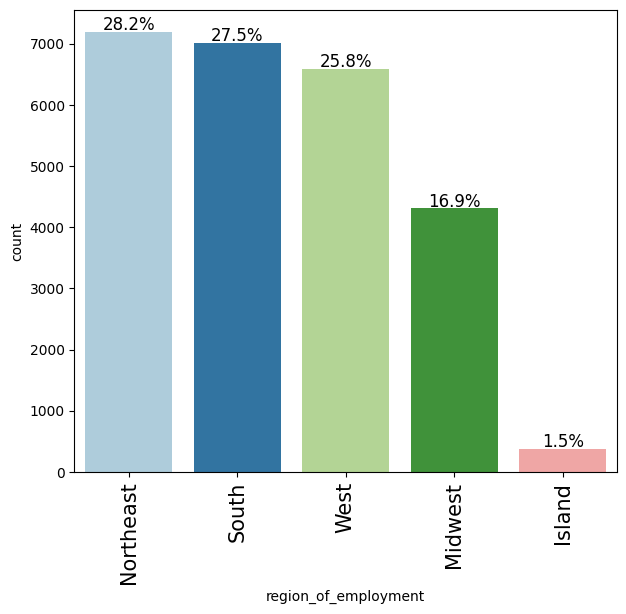

In [ ]:
labeled_barplot(df, "region_of_employment", perc=True)

Observations: 28.2% of applicants are searching for employment in the Northeast region of the United States. This is followed by 27.5% in the South and 25.8% in the West. Less applicants are looking for employment in the Midwest and Island regions of the United States.

#### Prevailing Wage

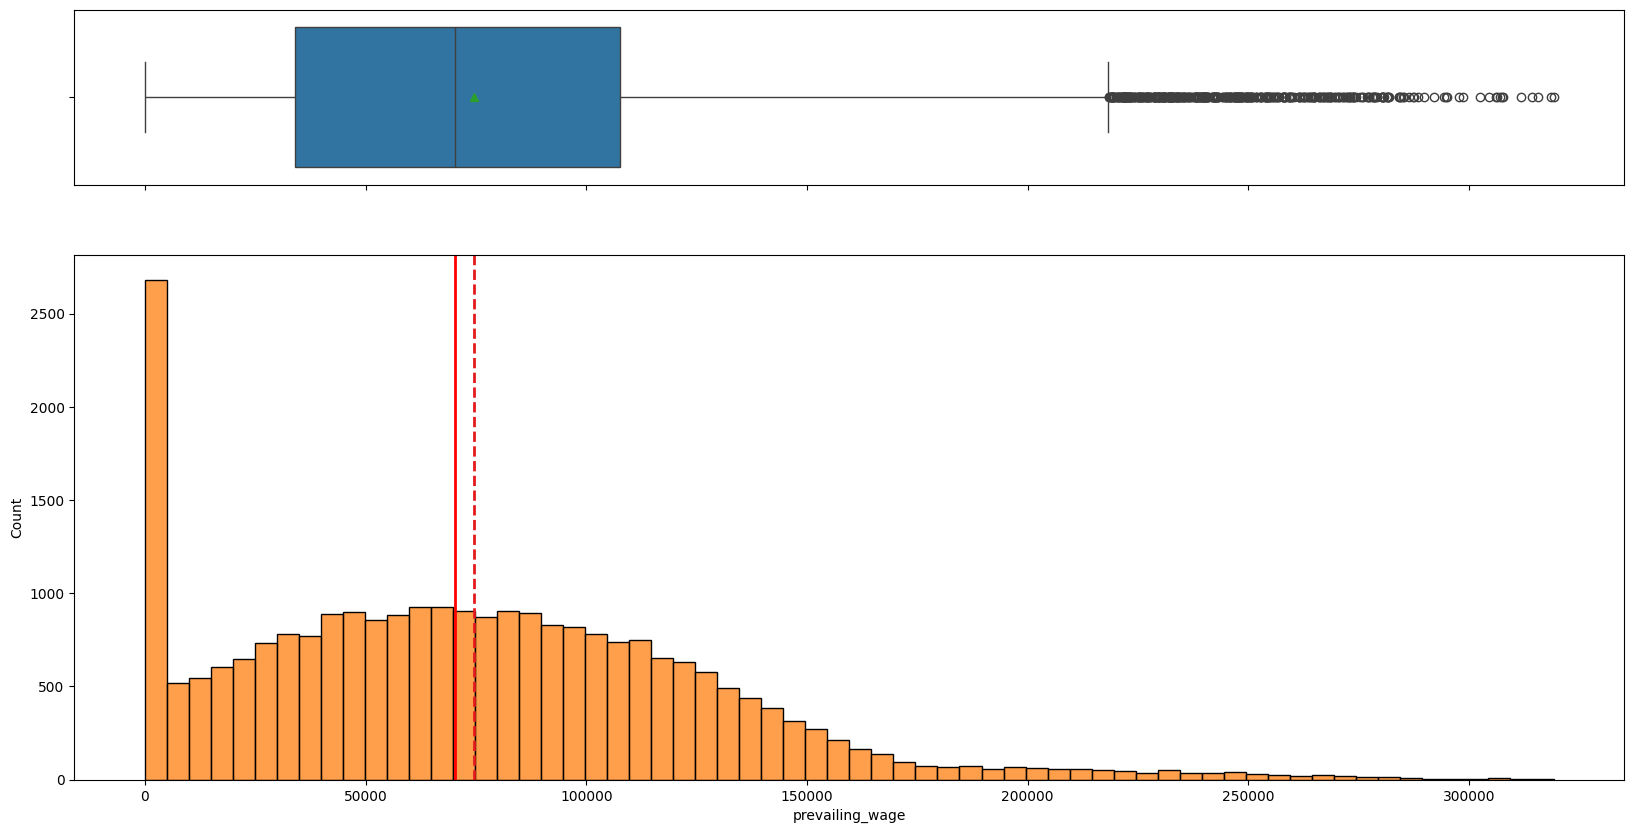

In [ ]:
histogram_boxplot(df, "prevailing_wage")

In [ ]:
np.mean(df["prevailing_wage"])

74455.81459209183

Observations: The average prevailing wage is about $74456.

#### Unit of Wage

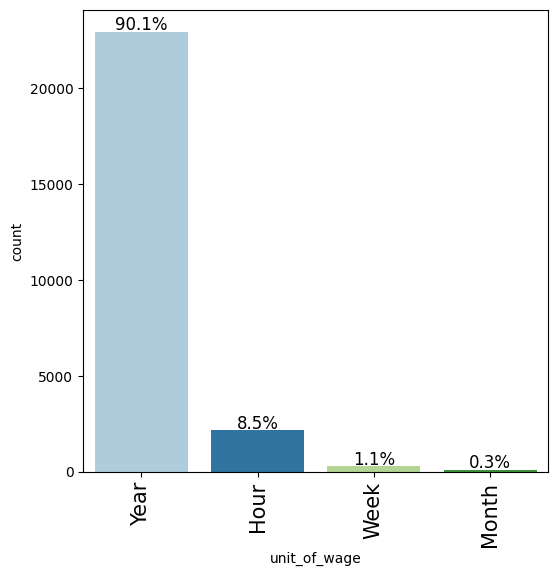

In [ ]:
labeled_barplot(df, "unit_of_wage", perc=True)

Observations: 90.1% of applicants are paid yearly and 8.5% are paid hourly.

#### Full-time Position

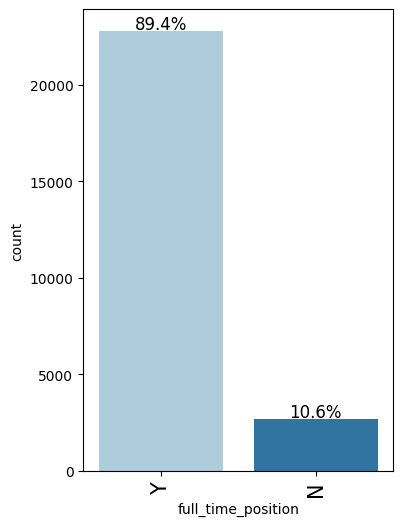

In [ ]:
labeled_barplot(df, "full_time_position", perc=True)

Observations: 89.4% of applicants are working full-time and 10.6% are working part-time.

#### Case Status

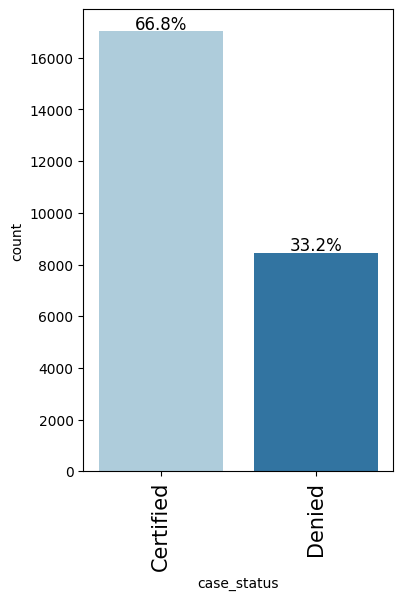

In [ ]:
labeled_barplot(df, "case_status", perc=True)

Observations: Most applicants are certified (66.8%) while the rest are denied (33.2%).

### Multivariate Analysis

#### Correlation Heatmap

<Axes: >

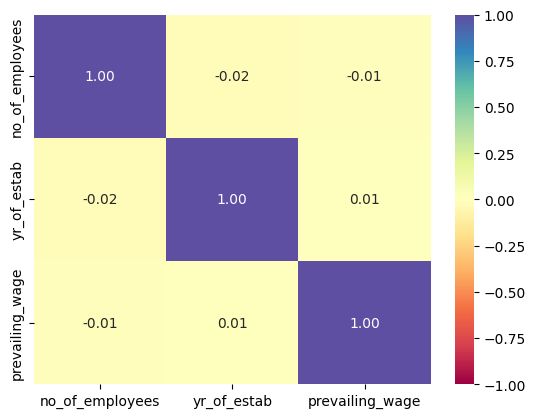

In [ ]:
# displays heatmap of numerical attributes
cols = df.select_dtypes(include=np.number).columns.tolist()
sns.heatmap(df[cols].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")

Observations: All numerical categories have little to no correlation to each other.

#### Education vs. Case Status

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


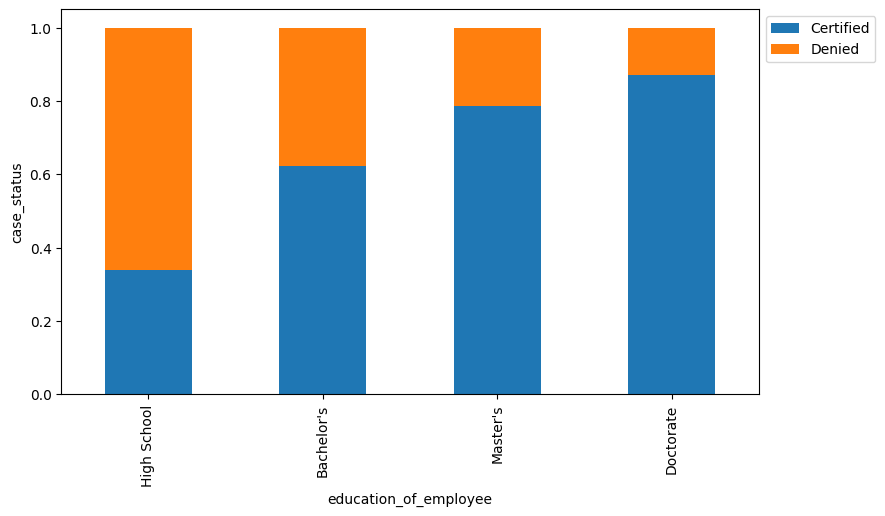

In [ ]:
# displays proportion of certifications per education level
stacked_barplot(df, "education_of_employee", "case_status")

Observations: The prevailing wage is about the same for each education level.

#### Education vs. Prevailing Wage

<Axes: xlabel='education_of_employee', ylabel='prevailing_wage'>

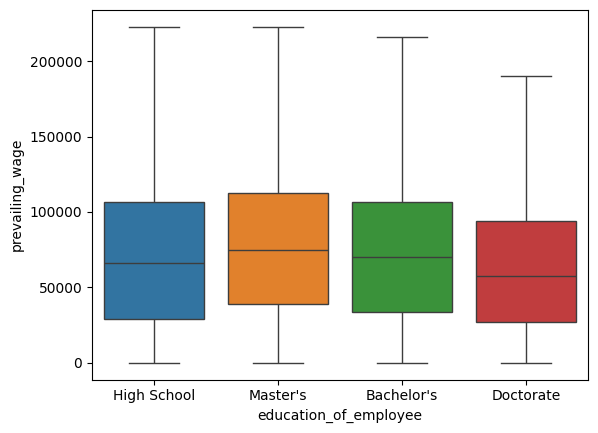

In [ ]:
# displays distribution of prevailing wage per education level
sns.boxplot(data=df, x="education_of_employee", y="prevailing_wage", palette="tab10", showfliers=False)

Observations: The prevailing wage distrubution is similar for all education levels.

#### Continent vs. Case Status

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


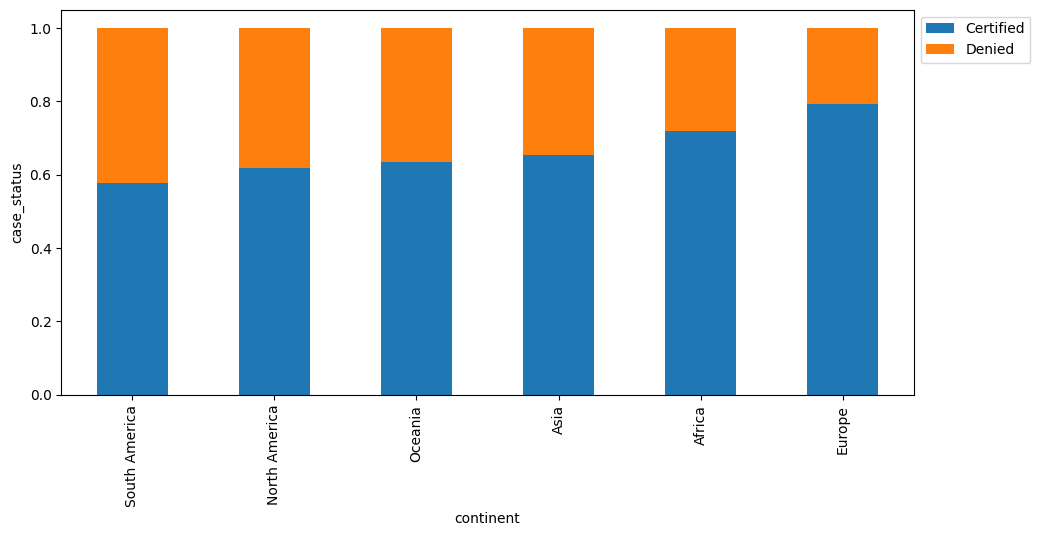

In [ ]:
# displays proportion of certification per continent
stacked_barplot(df, "continent", "case_status")

Observations: Europe has the highest certification rates, followed by Africa. Asia, Oceania, and North America have similar rates, while South America has the lowest.

#### Continent vs. Prevailing Wage

<Axes: xlabel='continent', ylabel='prevailing_wage'>

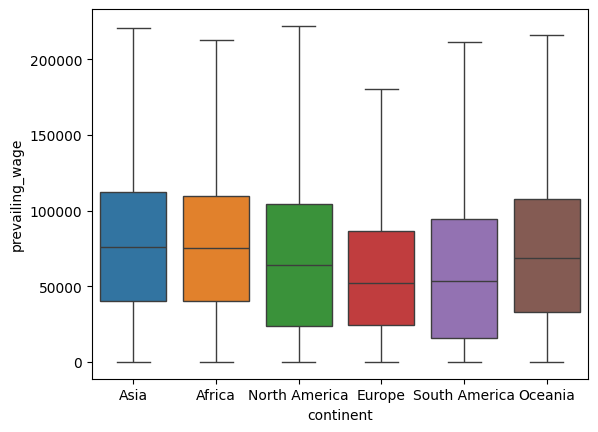

In [ ]:
# displays distribution of prevailing wage per continent
sns.boxplot(data=df, x="continent", y="prevailing_wage", palette="tab10", showfliers=False)

Observations: The distributions for each continent slightly vary, but are not statistically different.

#### Continent vs. Education

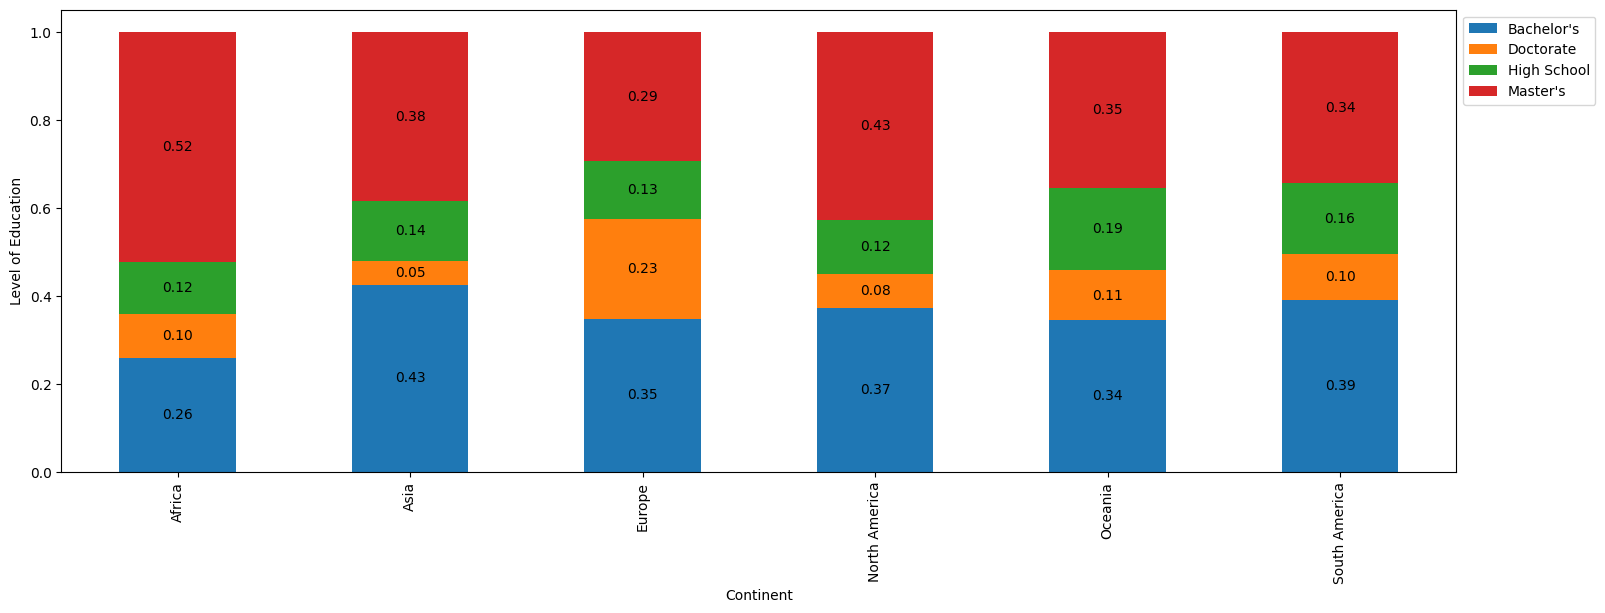

In [ ]:
# displays the percentage of education level for each continent
ax = pd.crosstab(df["continent"], df["education_of_employee"], normalize = "index").plot(kind = "bar", stacked = True, figsize = (18, 6))
for c in ax.containers:
  ax.bar_label(c, label_type = "center", fmt="%.2f")

plt.xlabel("Continent")
plt.ylabel("Level of Education")
plt.legend(bbox_to_anchor = (1, 1))
plt.show()

Observations: Master's is the largest cohort in the Africa, North America, and Oceania data. Bachelor's is the greatest in the Asia, Europe, and South America data.

#### Job Experience vs. Case Status

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


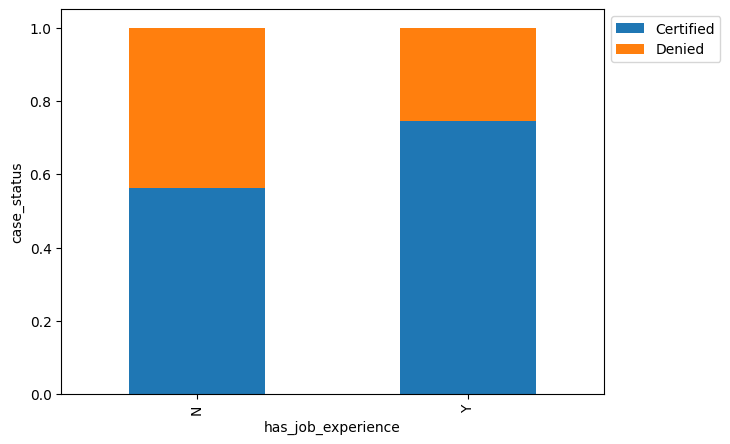

In [ ]:
# displays proportion of case status for job experience
stacked_barplot(df, "has_job_experience", "case_status")

Observations: Employees with job experience have higher certification rates than those who do not.

#### Job Experience vs. Prevailing Wage

<Axes: xlabel='has_job_experience', ylabel='prevailing_wage'>

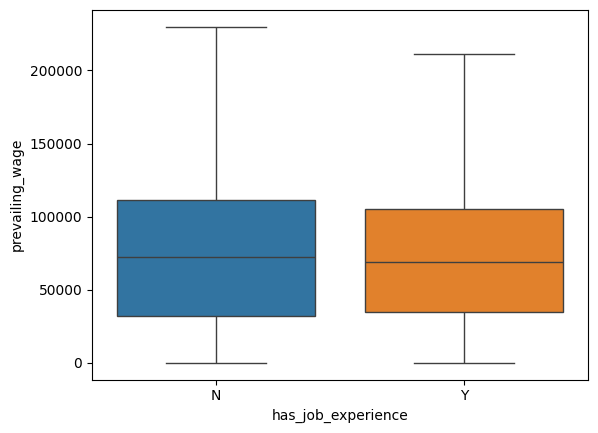

In [ ]:
# displays the distribution of prevailing wage for job experiences
sns.boxplot(data=df, x="has_job_experience", y="prevailing_wage", palette="tab10", showfliers=False)

Observations: Job experience does not seem to affect the distribution of prevailing wage.

#### Job Experience vs. Job Training

requires_job_training      N     Y    All
has_job_experience                       
All                    22525  2955  25480
N                       8988  1690  10678
Y                      13537  1265  14802
------------------------------------------------------------------------------------------------------------------------


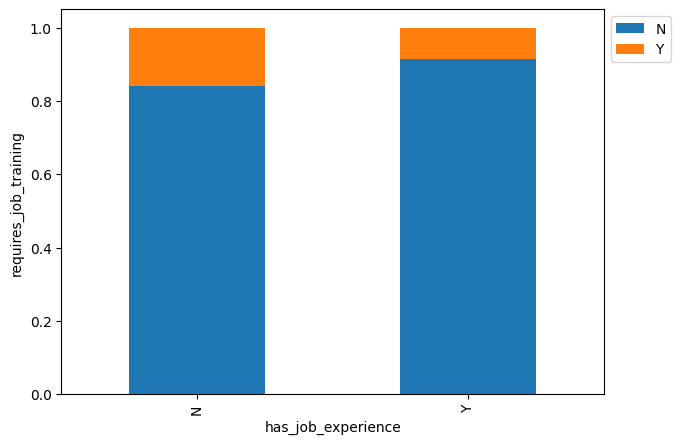

In [ ]:
# displays the proportion of training required for each level of job experience
stacked_barplot(df, "has_job_experience", "requires_job_training")

Observations: About 80% of applicants that do not have job experience do not require job training, while 90% of applicants that have experience do not require training.

#### Wage Interval vs. Case Status

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


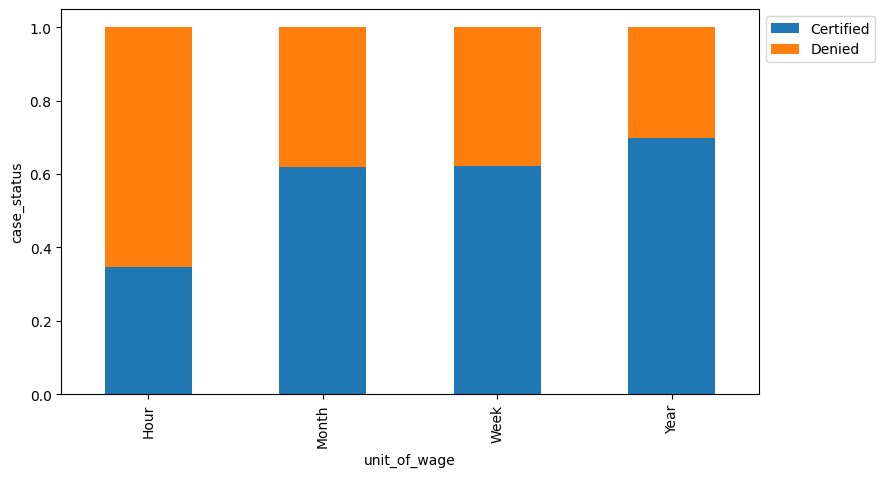

In [ ]:
# displays certification rates for each wage interval
stacked_barplot(df, "unit_of_wage", "case_status")

Observations: Employees with yearly wages have the highest certification proportion, while employees with hourly wages have the lowest.

#### Prevailing Wage vs. Case Status

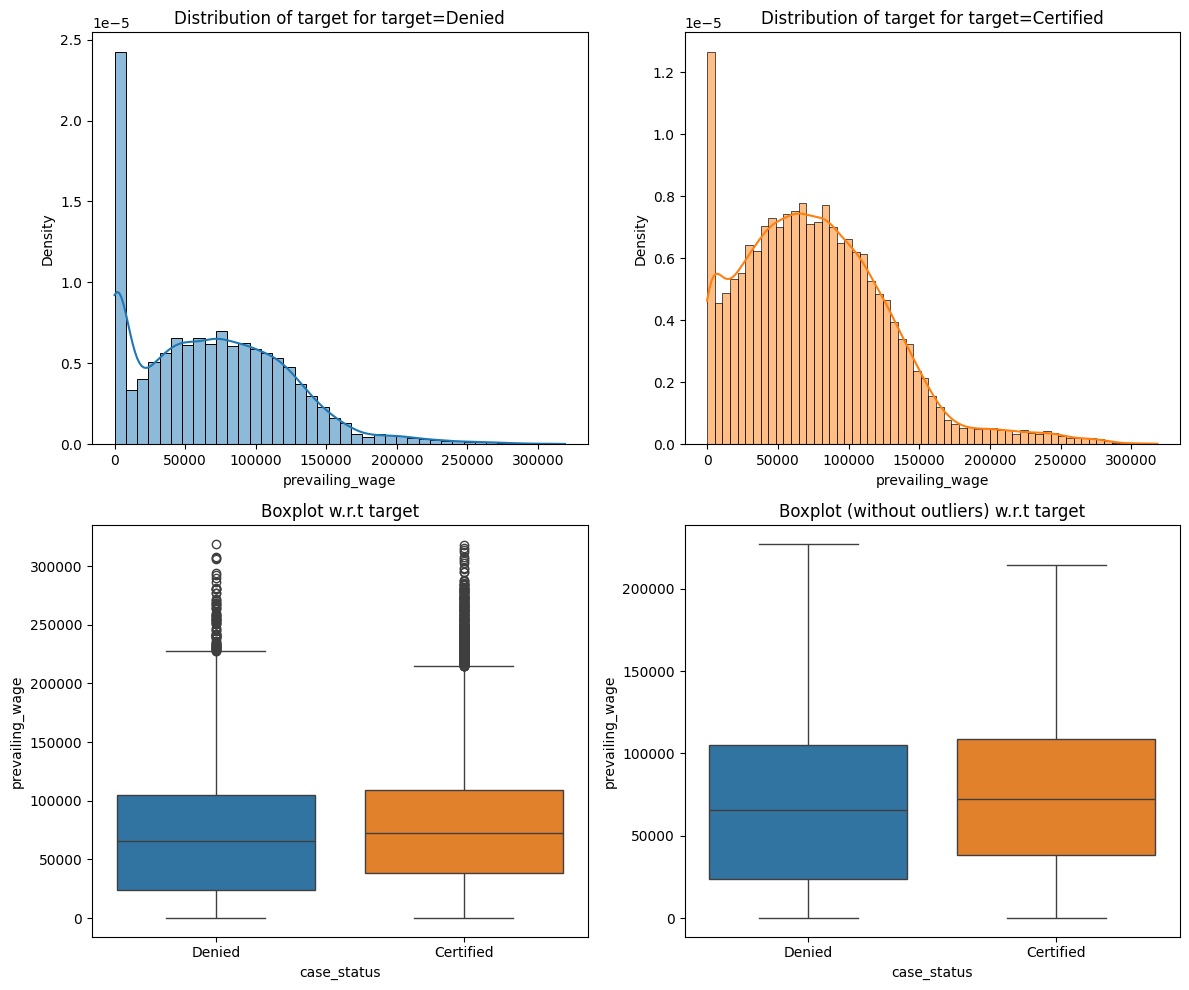

In [ ]:
# displays distribution of prevailing wage for each case status
distribution_plot_wrt_target(df, "prevailing_wage", "case_status")

Observations: Prevailing wages are similar for both visa statuses.

#### Region of Employment vs. Case Status

case_status           Certified  Denied    All
region_of_employment                          
All                       17018    8462  25480
Northeast                  4526    2669   7195
West                       4100    2486   6586
South                      4913    2104   7017
Midwest                    3253    1054   4307
Island                      226     149    375
------------------------------------------------------------------------------------------------------------------------


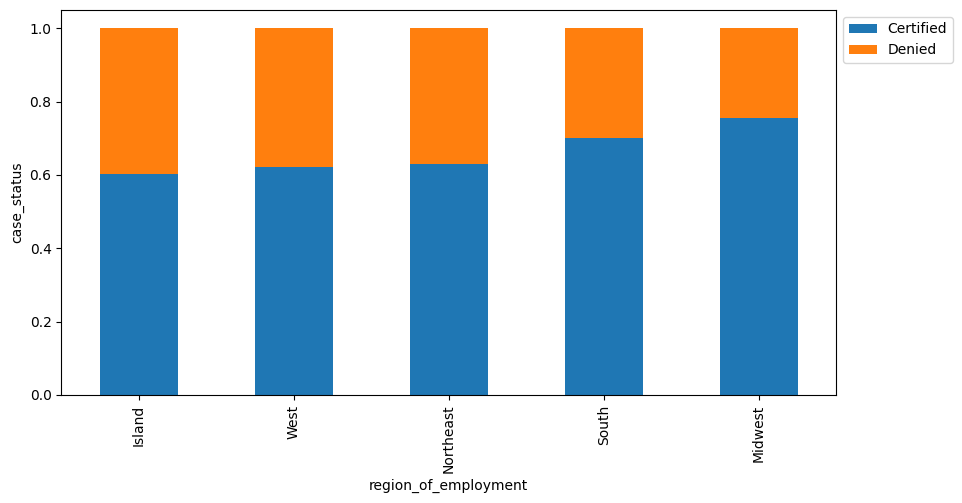

In [ ]:
# displays certification rates per region of employment
stacked_barplot(df, "region_of_employment", "case_status")

Observations: The certification rate is about the same for the Island, West, and Northeast regions. Certification rates are slightly higher in the South and Midwest regions.

#### Region of Employment vs. Prevailing Wage

<Axes: xlabel='region_of_employment', ylabel='prevailing_wage'>

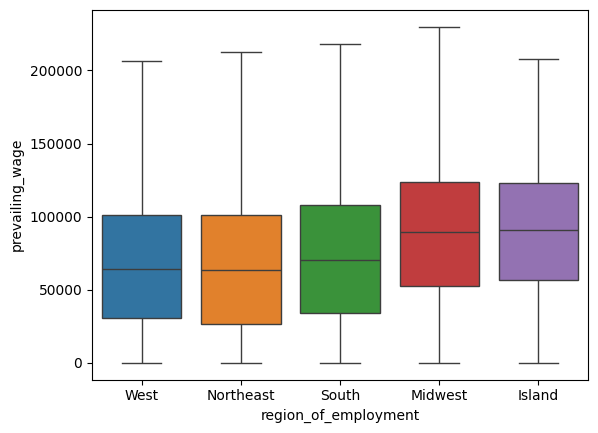

In [ ]:
# displays distributions of prevailing wage per region of employment
sns.boxplot(data=df, x="region_of_employment", y="prevailing_wage", palette="tab10", showfliers=False)

Observations: The distrubution of prevailing wage is about the same in the West, Northeast, and South regions. The median is slightly greater in the Midwest and Island regions, but the distributions are not statistically different.

#### Region of Employment vs. Education

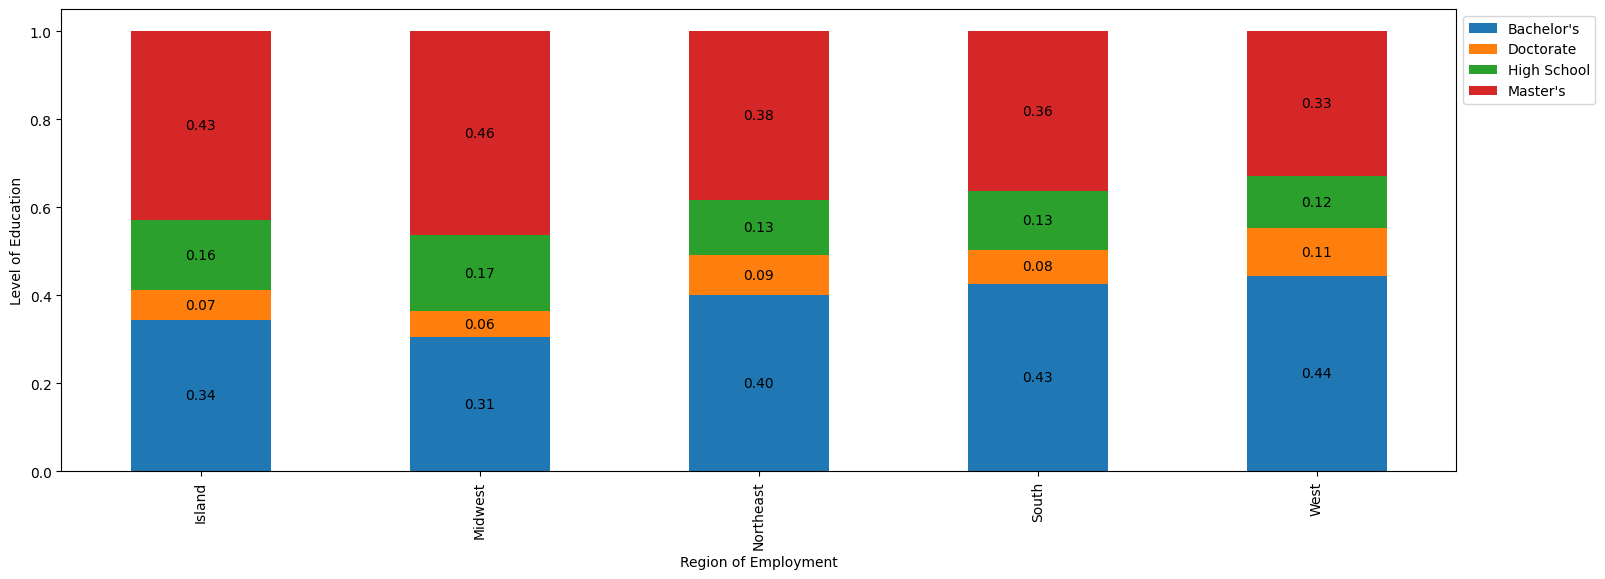

In [ ]:
# displays the percentage of each education level per region of employment
ax = pd.crosstab(df["region_of_employment"], df["education_of_employee"], normalize = "index").plot(kind = "bar", stacked = True, figsize = (18, 6))
for c in ax.containers:
  ax.bar_label(c, label_type = "center", fmt="%.2f")

plt.xlabel("Region of Employment")
plt.ylabel("Level of Education")
plt.legend(bbox_to_anchor = (1, 1))
plt.show()

Observations: The largest cohort of the Island and Midwest regions is Master's. The largest cohort of the other regions is Bachelor's. The doctorate cohort is the larger in the West region than the others.

#### Job Schedule vs. Case Status

case_status         Certified  Denied    All
full_time_position                          
All                     17018    8462  25480
Y                       15163    7610  22773
N                        1855     852   2707
------------------------------------------------------------------------------------------------------------------------


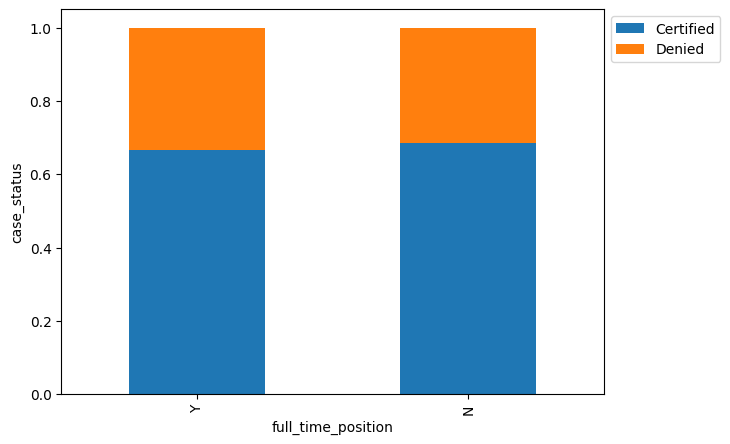

In [ ]:
# displays certification rates for full time and part time positions
stacked_barplot(df, "full_time_position", "case_status")

Observations: The job schedule does not seem to impact visa certification.

## Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

### Outlier Detection

In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

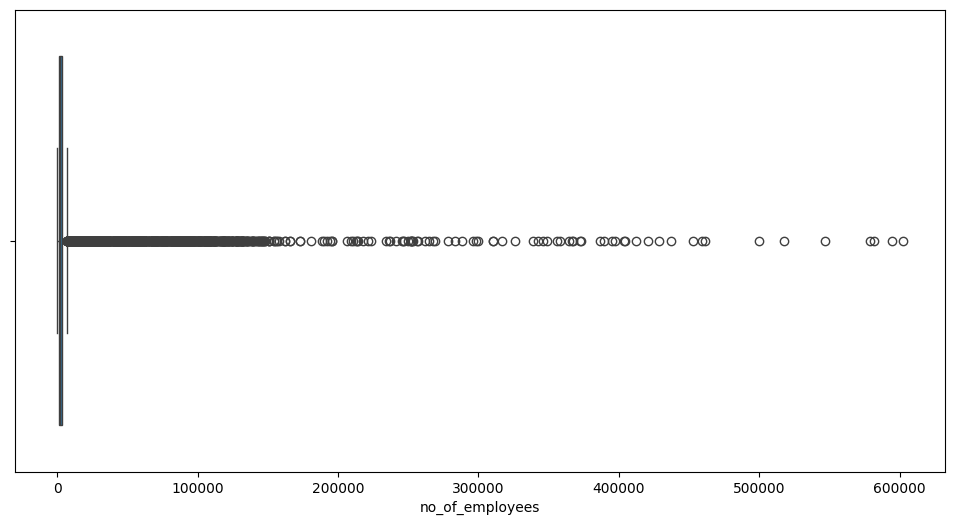

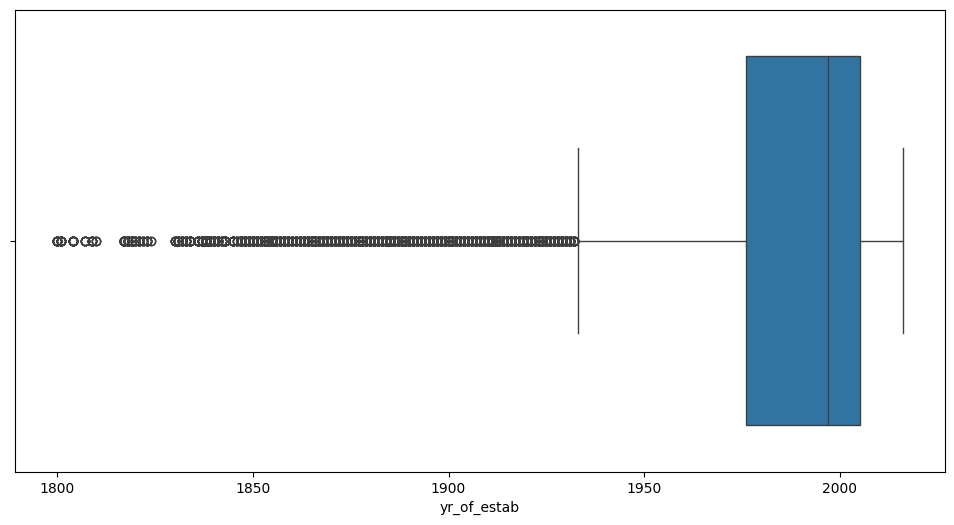

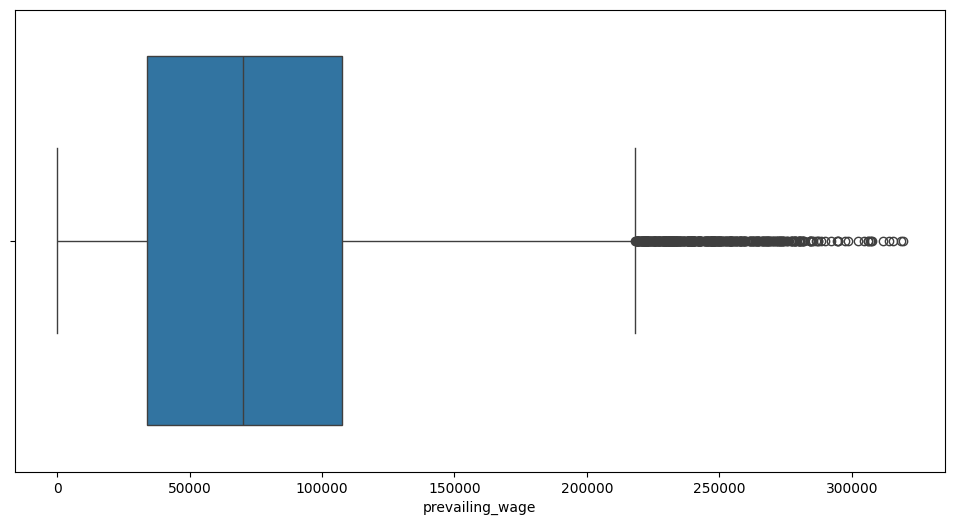

In [ ]:
for x in numeric_columns:
  plt.figure(figsize=(12, 6))
  sns.boxplot(data=df, x=x)
  plt.show()
  print()

### Feature Engineering

In [ ]:
df["case_status"] = df["case_status"].map({"Certified": 1, "Denied": 0})

### Data Preparation for Modeling

In [ ]:
X = df.drop("case_status", axis=1)
y = df["case_status"]

X = pd.get_dummies(X)

# splitting data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

In [ ]:
# verifying split
print("Shape of training set: ", X_train.shape)
print("Shape of test set: ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of training set:  (17836, 28)
Shape of test set:  (7644, 28)
Percentage of classes in training set:
1    0.667919
0    0.332081
Name: case_status, dtype: float64
Percentage of classes in test set:
1    0.667844
0    0.332156
Name: case_status, dtype: float64


Observations: Around 67% of cases are certified and 33% are denied. This is preserved in both the training and test sets.

### Custom Functions

In [ ]:
def model_performance_classification_sklearn(model, predictors, target):
    pre = model.predict(predictors)
    acc = accuracy_score(target, pre)
    recall = recall_score(target, pre)
    precision = precision_score(target, pre)
    f1 = f1_score(target, pre)
    performance = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )
    return performance

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    pre = model.predict(predictors)
    cm = confusion_matrix(target, pre)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

## EDA

- It is a good idea to explore the data once again after manipulating it.

In [ ]:
X.head()

,no_of_employees,yr_of_estab,prevailing_wage,continent_Africa,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,education_of_employee_Bachelor's,education_of_employee_Doctorate,education_of_employee_High School,education_of_employee_Master's,has_job_experience_N,has_job_experience_Y,requires_job_training_N,requires_job_training_Y,region_of_employment_Island,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,unit_of_wage_Hour,unit_of_wage_Month,unit_of_wage_Week,unit_of_wage_Year,full_time_position_N,full_time_position_Y
0,14513,2007,592.2029,0,1,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,1,1,0,0,0,0,1
1,2412,2002,83425.6500,0,1,0,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0,0,0,1,0,1
2,44444,2008,122996.8600,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,1
3,98,1897,83434.0300,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,1,0,1
4,1082,2005,149907.3900,1,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,1,0,0,0,0,1,0,1


X Train: 


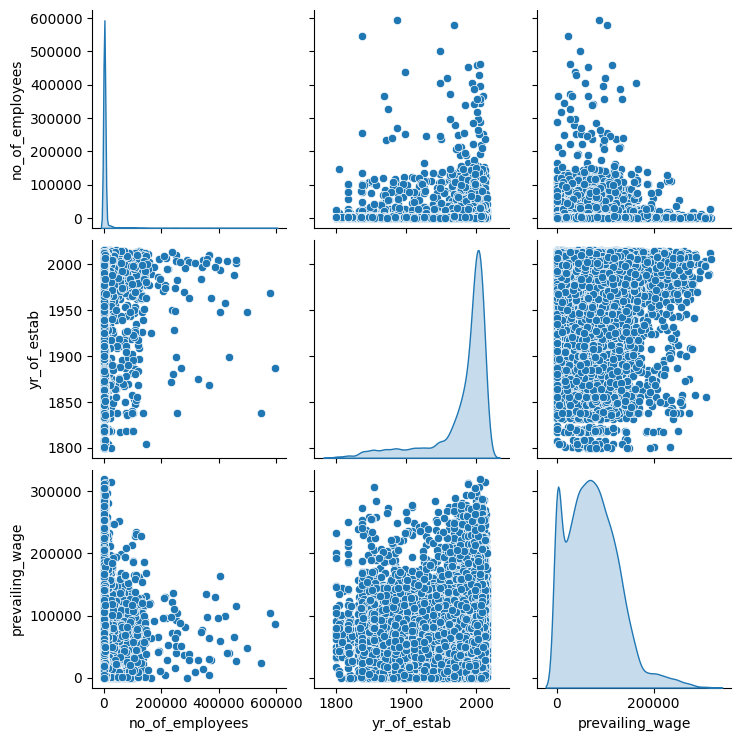


X Test: 


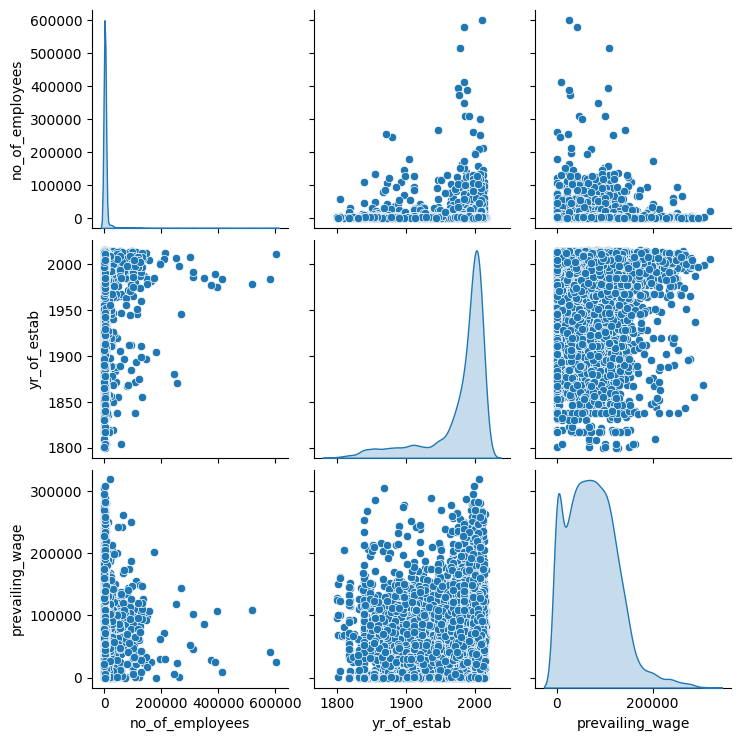

In [ ]:
# creates placeholders without dummies for split sets
nd_train = X_train.iloc[:, 0:3]
nd_test = X_test.iloc[:, 0:3]

print("X Train: ")
sns.pairplot(data=nd_train, diag_kind="kde")
plt.show()
print()
print("X Test: ")
sns.pairplot(data=nd_test, diag_kind="kde")
plt.show()

## Sample Parameter Grids


1. Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase

- For Gradient Boosting:

```
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}
```

- For Adaboost:

```
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}
```

- For Bagging Classifier:

```
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
```
- For Random Forest:

```
param_grid = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
```

- For Decision Trees:

```
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
```

- For XGBoost:

```
param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
}
```

## Decision Tree - Model and Hyperparameter Tuning

### Decision Tree Model

In [ ]:
# fitting model
tree = DecisionTreeClassifier(random_state=1)
tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

#### Training Set Performance

Training performance: 
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0



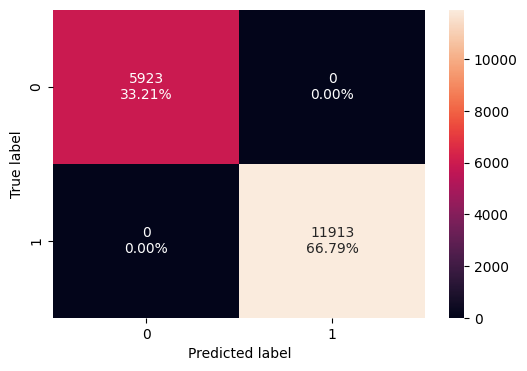

In [ ]:
tree_train_performance = model_performance_classification_sklearn(tree, X_train, y_train)
print("Training performance: \n", tree_train_performance)
print()
# checking model performance on training set
confusion_matrix_sklearn(tree, X_train, y_train)

#### Testing Set Performance

Testing performance: 
    Accuracy    Recall  Precision        F1
0  0.660387  0.739275   0.748958  0.744085



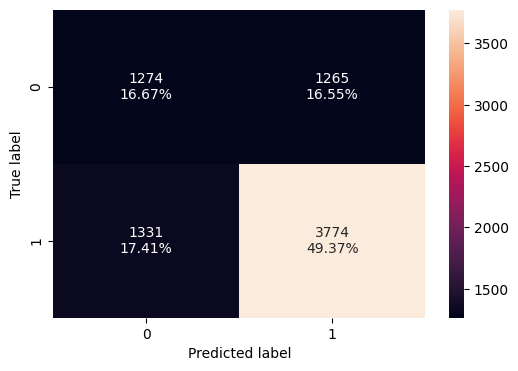

In [ ]:
tree_test_performance = model_performance_classification_sklearn(tree, X_test, y_test)
print("Testing performance: \n", tree_test_performance)
print()
# checking model performance on testing set
confusion_matrix_sklearn(tree, X_test, y_test)

Observations: The decision tree is overfitting the training data. There is a large difference between the train and test scores for all the metrics.

### Hyperparameter Tuning

In [ ]:
tree_estimator =  DecisionTreeClassifier(class_weight="balanced", random_state=1)
parameters={
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
scorer = metrics.make_scorer(metrics.f1_score)
grid_obj = GridSearchCV(tree_estimator, parameters, scoring=scorer, n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

tree_estimator = grid_obj.best_estimator_
tree_estimator.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, max_leaf_nodes=10,
                       min_impurity_decrease=0.0001, random_state=1)

Training performance: 
    Accuracy    Recall  Precision        F1
0  0.710529  0.726685   0.819481  0.770299



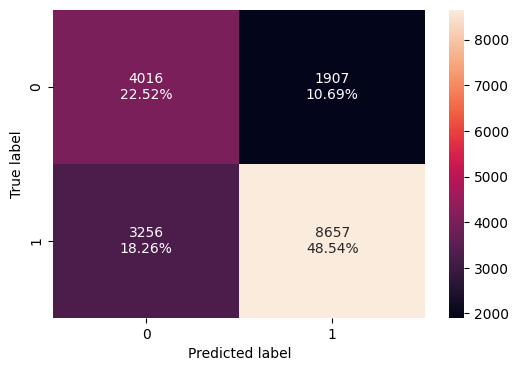

In [ ]:
tree_estimator_train_performance = model_performance_classification_sklearn(tree_estimator, X_train, y_train)
print("Training performance: \n", tree_estimator_train_performance)
print()
# checking model performance on training set
confusion_matrix_sklearn(tree_estimator, X_train, y_train)

Testing performance: 
    Accuracy   Recall  Precision        F1
0  0.708399  0.72811   0.815489  0.769326



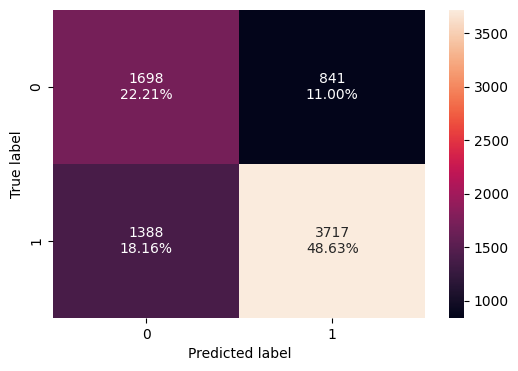

In [ ]:
tree_estimator_test_performance = model_performance_classification_sklearn(tree_estimator, X_test, y_test)
print("Testing performance: \n", tree_estimator_test_performance)
print()
# checking model performance on testing set
confusion_matrix_sklearn(tree_estimator, X_test, y_test)

Observations: The overfitting has reduced. The accuracy, precision, and F1 score increased in the test set.

## Bagging - Model and Hyperparameter Tuning

### Random Forest Model

In [ ]:
rf = RandomForestClassifier(random_state=1, class_weight="balanced")
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=1)

#### Training Set Performance

Training performance: 
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0



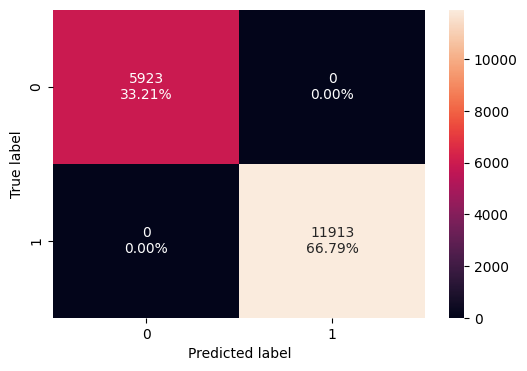

In [ ]:
rf_train_performance = model_performance_classification_sklearn(rf, X_train, y_train)
print("Training performance: \n", rf_train_performance)
print()
# checking model performance on training set
confusion_matrix_sklearn(rf, X_train, y_train)

#### Testing Set Performance

Testing performance: 
    Accuracy    Recall  Precision      F1
0  0.719911  0.835651   0.766164  0.7994



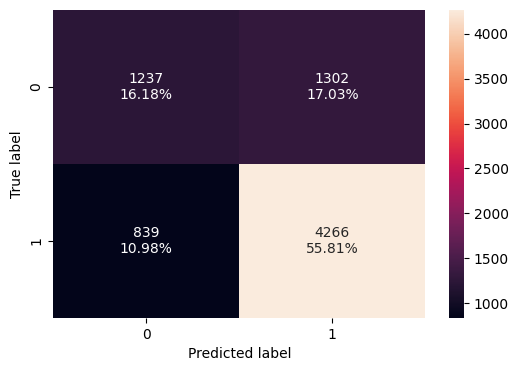

In [ ]:
rf_test_performance = model_performance_classification_sklearn(rf, X_test, y_test)
print("Testing performance: \n", rf_test_performance)
print()
# checking model performance on training set
confusion_matrix_sklearn(rf, X_test, y_test)

Observations: The random forest model is overfitting the training data and reporting lower metric scores than the decision tree model.

### Hyperparameter Tuning

In [ ]:
rf_tuned = RandomForestClassifier(random_state=1, class_weight="balanced", oob_score=True, bootstrap=True)
parameters={
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
scorer = metrics.make_scorer(metrics.f1_score)
grid_obj = GridSearchCV(rf_tuned, parameters, scoring=scorer, cv=5, n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

rf_tuned = grid_obj.best_estimator_
rf_tuned.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_samples=0.4,
                       n_estimators=110, oob_score=True, random_state=1)

Training performance: 
    Accuracy   Recall  Precision        F1
0   0.91534  0.97146   0.908185  0.938757



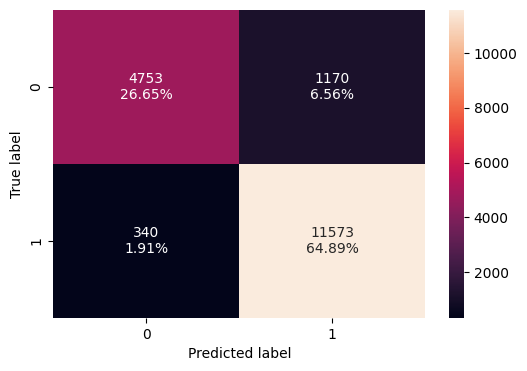

In [ ]:
rf_tuned_train_performance = model_performance_classification_sklearn(rf_tuned, X_train, y_train)
print("Training performance: \n", rf_tuned_train_performance)
print()
# checking model performance on training set
confusion_matrix_sklearn(rf_tuned, X_train, y_train)

Testing performance: 
    Accuracy    Recall  Precision       F1
0  0.734563  0.860529   0.769352  0.81239



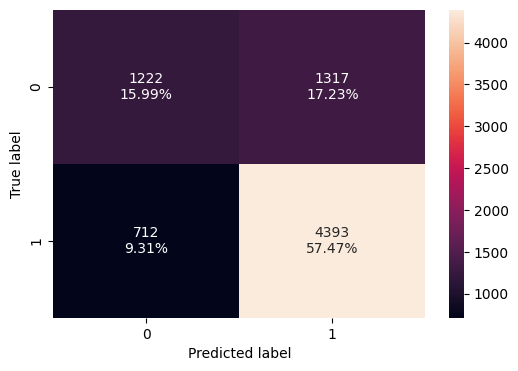

In [ ]:
rf_tuned_test_performance = model_performance_classification_sklearn(rf_tuned, X_test, y_test)
print("Testing performance: \n", rf_tuned_test_performance)
print()
# checking model performance on testing set
confusion_matrix_sklearn(rf_tuned, X_test, y_test)

Observations: The overfitting has slightly decreased and all metrics have slightly improved.

### Bagging Classifier

In [ ]:
bc = BaggingClassifier(random_state=1)
bc.fit(X_train, y_train)

BaggingClassifier(random_state=1)

#### Training Set Performance

Training performance: 
    Accuracy    Recall  Precision        F1
0  0.983797  0.984639   0.991044  0.987831



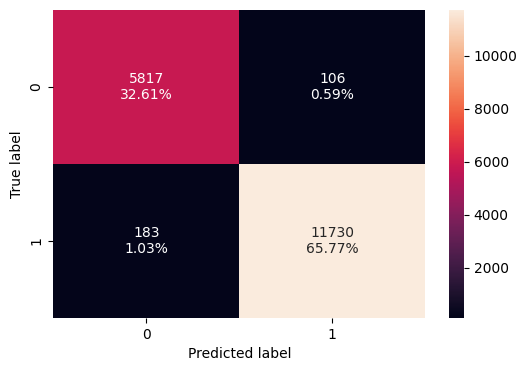

In [ ]:
bc_train_performance = model_performance_classification_sklearn(bc, X_train, y_train)
print("Training performance: \n", bc_train_performance)
print()
# checking model performance on training set
confusion_matrix_sklearn(bc, X_train, y_train)

#### Testing Set Performance

Testing performance: 
    Accuracy    Recall  Precision        F1
0  0.704212  0.777081   0.779371  0.778225



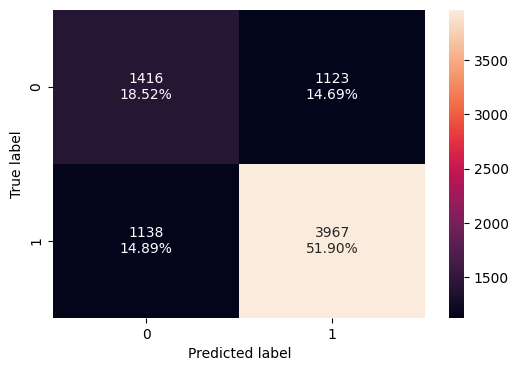

In [ ]:
bc_test_performance = model_performance_classification_sklearn(bc, X_test, y_test)
print("Testing performance: \n", bc_test_performance)
print()
# checking model performance on testing set
confusion_matrix_sklearn(bc, X_test, y_test)

Observations: The bagging classifier is overfitting the training data.

### Hyperparameter Tuning

In [ ]:
bc_tuned = BaggingClassifier(random_state=1)
parameters={
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
  }
scorer = metrics.make_scorer(metrics.f1_score)
grid_obj = GridSearchCV(bc_tuned, parameters, scoring=scorer, cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

bc_tuned = grid_obj.best_estimator_
bc_tuned.fit(X_train, y_train)

BaggingClassifier(max_features=0.7, max_samples=0.8, n_estimators=70,
                  random_state=1)

Testing performance: 
    Accuracy    Recall  Precision        F1
0  0.997813  0.999748   0.996986  0.998365



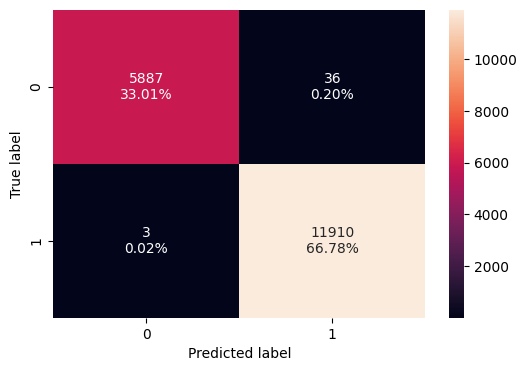

In [ ]:
bc_tuned_train_performance = model_performance_classification_sklearn(bc_tuned, X_train, y_train)
print("Testing performance: \n", bc_tuned_train_performance)
print()
# checking model performance on training set
confusion_matrix_sklearn(bc_tuned, X_train, y_train)

Testing performance: 
    Accuracy    Recall  Precision        F1
0  0.730246  0.869344   0.760843  0.811483



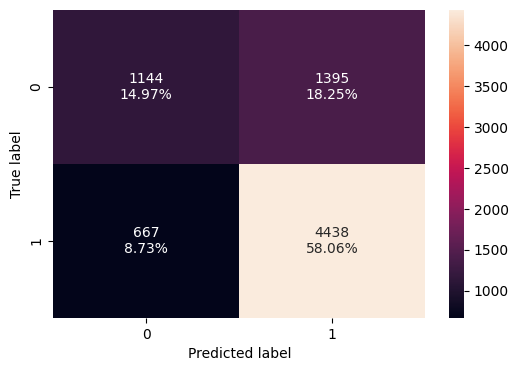

In [ ]:
bc_tuned_test_performance = model_performance_classification_sklearn(bc_tuned, X_test, y_test)
print("Testing performance: \n", bc_tuned_test_performance)
print()
# checking model performance on testing set
confusion_matrix_sklearn(bc_tuned, X_test, y_test)

Observations: Overfitting decreased slightly. All metrics except precision improved.

## Boosting - Model and Hyperparameter Tuning

### AdaBoost Classifier

In [ ]:
ab_classifier = AdaBoostClassifier(random_state=1)
ab_classifier.fit(X_train, y_train)

AdaBoostClassifier(random_state=1)

#### Training Set Performance

Training performance: 
    Accuracy    Recall  Precision       F1
0  0.738058  0.886259   0.760937  0.81883



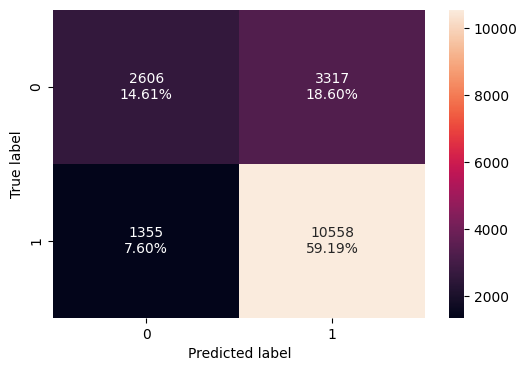

In [ ]:
ab_classifier_train_performance = model_performance_classification_sklearn(ab_classifier, X_train, y_train)
print("Training performance: \n", ab_classifier_train_performance)
print()
# checking model performance on training set
confusion_matrix_sklearn(ab_classifier, X_train, y_train)

#### Testing Set Performance

Testing performance: 
    Accuracy    Recall  Precision        F1
0  0.734301  0.883252    0.75858  0.816182



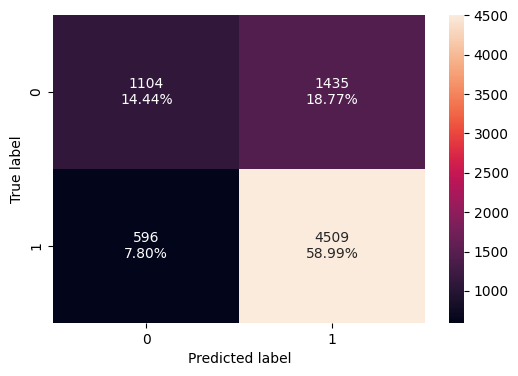

In [ ]:
ab_classifier_test_performance = model_performance_classification_sklearn(ab_classifier, X_test, y_test)
print("Testing performance: \n", ab_classifier_test_performance)
print()
# checking model performance on test set
confusion_matrix_sklearn(ab_classifier, X_test, y_test)

Observations: AdaBoost is not overfitting, unlike some of the previous models. The train and test performances are very similar.

### Hyperparameter Tuning

In [ ]:
ab_tuned = AdaBoostClassifier(random_state=1)
parameters={
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}
scorer = metrics.make_scorer(metrics.f1_score)
grid_obj = GridSearchCV(ab_tuned, parameters, scoring=scorer, cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

ab_tuned = grid_obj.best_estimator_
ab_tuned.fit(X_train, y_train)

AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=3,
                                                         random_state=1),
                   learning_rate=0.05, n_estimators=100, random_state=1)

Training performance: 
    Accuracy   Recall  Precision        F1
0  0.753869  0.88735   0.776195  0.828059



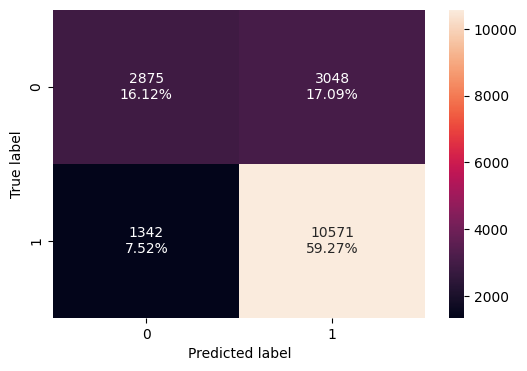

In [ ]:
ab_tuned_train_performance = model_performance_classification_sklearn(ab_tuned, X_train, y_train)
print("Training performance: \n", ab_tuned_train_performance)
print()
confusion_matrix_sklearn(ab_tuned, X_train, y_train)

Testing performance: 
    Accuracy    Recall  Precision        F1
0  0.743851  0.881881   0.768653  0.821383



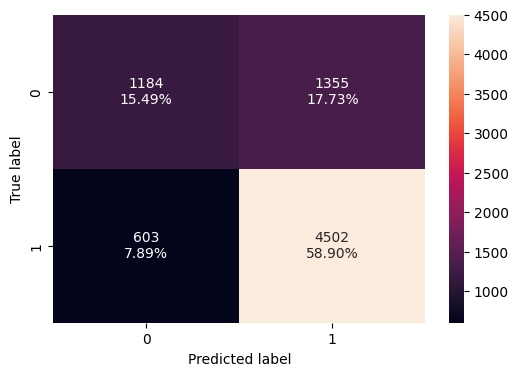

In [ ]:
ab_tuned_test_performance = model_performance_classification_sklearn(ab_tuned, X_test, y_test)
print("Testing performance: \n", ab_tuned_test_performance)
print()
confusion_matrix_sklearn(ab_tuned, X_test, y_test)

Observations: Precision and accuracy slightly improved.

### Gradient Boosting Classifier

In [ ]:
gb_classifier = GradientBoostingClassifier(random_state=1)
gb_classifier.fit(X_train, y_train)

GradientBoostingClassifier(random_state=1)

#### Training Set Performance

Training performance: 
    Accuracy    Recall  Precision       F1
0  0.757849  0.883657   0.782095  0.82978



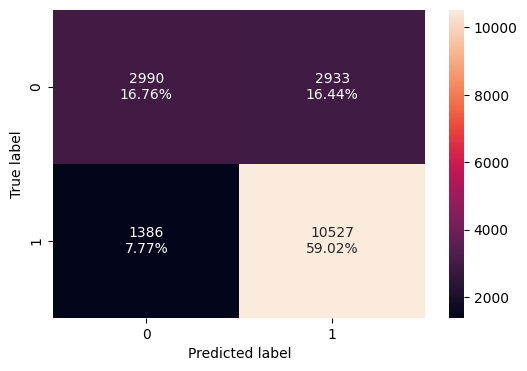

In [ ]:
gb_classifier_train_performance = model_performance_classification_sklearn(gb_classifier, X_train, y_train)
print("Training performance: \n", gb_classifier_train_performance)
print()
confusion_matrix_sklearn(gb_classifier, X_train, y_train)

#### Testing Set Performance

Testing performance: 
    Accuracy    Recall  Precision        F1
0  0.745814  0.878355   0.772305  0.821923



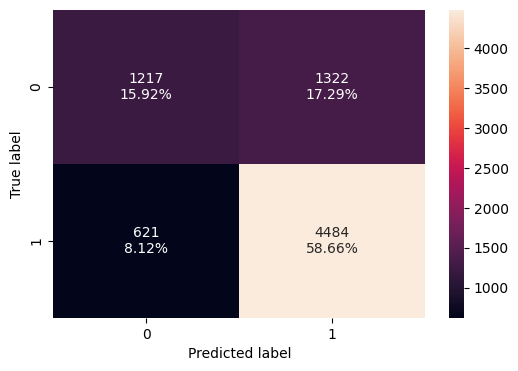

In [ ]:
gb_classifier_test_performance = model_performance_classification_sklearn(gb_classifier, X_test, y_test)
print("Testing performance: \n", gb_classifier_test_performance)
print()
confusion_matrix_sklearn(gb_classifier, X_test, y_test)

Observations: This model is not overfitting, little variance in metrics between train and test data.

### Hyperparameter Tuning

In [ ]:
gb_tuned = GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1), random_state=1)
parameters={
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}
scorer = metrics.make_scorer(metrics.f1_score)
grid_obj = GridSearchCV(gb_tuned, parameters, scoring=scorer, cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

gb_tuned = grid_obj.best_estimator_
gb_tuned.fit(X_train, y_train)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           max_features=0.7, n_estimators=50, random_state=1,
                           subsample=0.9)

Training performance: 
    Accuracy    Recall  Precision        F1
0  0.753756  0.885671   0.776894  0.827724



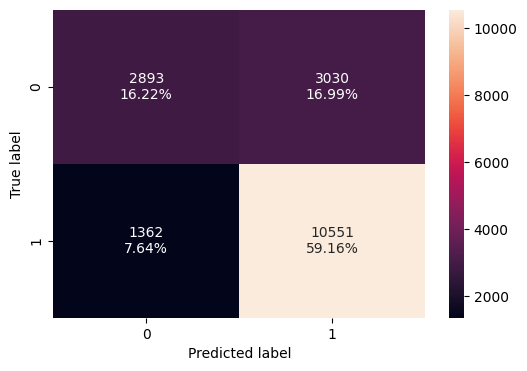

In [ ]:
gb_tuned_train_performance = model_performance_classification_sklearn(gb_tuned, X_train, y_train)
print("Training performance: \n", gb_tuned_train_performance)
print()
confusion_matrix_sklearn(gb_tuned, X_train, y_train)

Testing performance: 
    Accuracy    Recall  Precision        F1
0  0.745029  0.881489   0.770021  0.821993



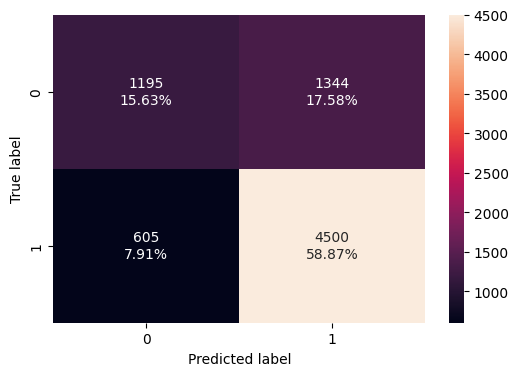

In [ ]:
gb_tuned_test_performance = model_performance_classification_sklearn(gb_tuned, X_test, y_test)
print("Testing performance: \n", gb_tuned_test_performance)
print()
confusion_matrix_sklearn(gb_tuned, X_test, y_test)

Observations: Minimal difference in model performance after hyperparameter tuning.

### XGBoost Classifier

In [ ]:
xgb_classifier = XGBClassifier(random_state=1, eval_metric="logloss")
xgb_classifier.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=1, ...)

#### Training Set Performance

Training performance: 
    Accuracy    Recall  Precision        F1
0  0.840884  0.930664     0.8464  0.886534



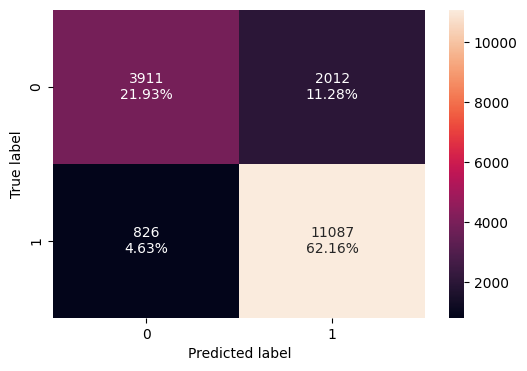

In [ ]:
xgb_classifier_train_performance = model_performance_classification_sklearn(xgb_classifier, X_train, y_train)
print("Training performance: \n", xgb_classifier_train_performance)
print()
confusion_matrix_sklearn(xgb_classifier, X_train, y_train)

#### Testing Set Performance

Testing performance: 
    Accuracy    Recall  Precision       F1
0  0.726583  0.850735   0.765826  0.80605



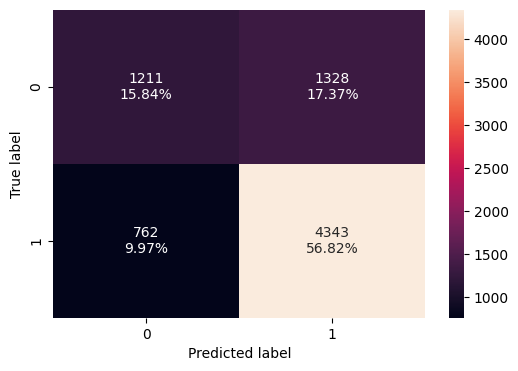

In [ ]:
xgb_classifier_test_performance = model_performance_classification_sklearn(xgb_classifier, X_test, y_test)
print("Testing performance: \n", xgb_classifier_test_performance)
print()
confusion_matrix_sklearn(xgb_classifier, X_test, y_test)

Observations: The model is slightly overfitting the train data.

### Hyperparameter Tuning

In [ ]:
xgb_tuned = XGBClassifier(random_state=1, eval_metric="logloss")
parameters={
    'n_estimators':np.arange(50,110,25),
    'scale_pos_weight':[1,2,5],
    'learning_rate':[0.01,0.1,0.05],
    'gamma':[1,3],
    'subsample':[0.7,0.9]
}
scorer = metrics.make_scorer(metrics.f1_score)
grid_obj = GridSearchCV(xgb_tuned, parameters, scoring=scorer, cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

xgb_tuned = grid_obj.best_estimator_
xgb_tuned.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=3, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50,
              n_jobs=None, num_parallel_tree=None, random_state=1, ...)

Training performance: 
    Accuracy   Recall  Precision       F1
0  0.759475  0.89247   0.779415  0.83212



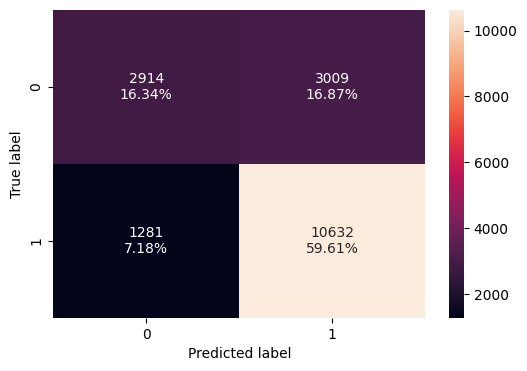

In [ ]:
xgb_tuned_train_performance = model_performance_classification_sklearn(xgb_tuned, X_train, y_train)
print("Training performance: \n", xgb_tuned_train_performance)
print()
confusion_matrix_sklearn(xgb_tuned, X_train, y_train)

Testing performance: 
    Accuracy    Recall  Precision        F1
0  0.743851  0.882076   0.768561  0.821416



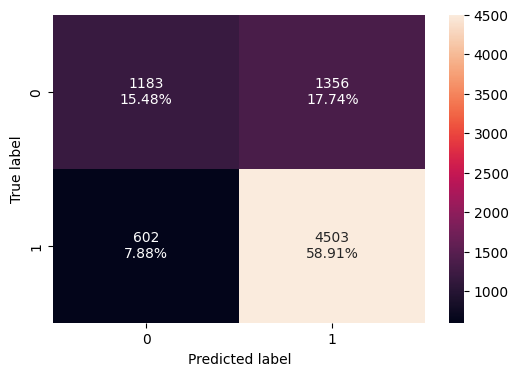

In [ ]:
xgb_tuned_test_performance = model_performance_classification_sklearn(xgb_tuned, X_test, y_test)
print("Testing performance: \n", xgb_tuned_test_performance)
print()
confusion_matrix_sklearn(xgb_tuned, X_test, y_test)

Observations: All metrics slightly increased without overfitting the train data.

## Stacking Model

In [ ]:
estimators = [("AdaBoost", ab_tuned), ("Gradient Boosting", gb_tuned), ("Random Forest", rf_tuned)]
final_estimator = xgb_tuned
stacking_classifier = StackingClassifier(estimators=estimators, final_estimator=final_estimator)
stacking_classifier.fit(X_train, y_train)

StackingClassifier(estimators=[('AdaBoost',
                                AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=3,
                                                                                         random_state=1),
                                                   learning_rate=0.05,
                                                   n_estimators=100,
                                                   random_state=1)),
                               ('Gradient Boosting',
                                GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                                                           max_features=0.7,
                                                           n_estimators=50,
                                                           random_state=1,
                                                           subsample=0.9)),
                               ('Random Forest',
                                Ra...
                                                 feature_types=None, gamma=3,
                                                 grow_policy=None,
                                                 importance_type=None,
                                                 interaction_constraints=None,
                                                 learning_rate=0.05,
                                                 max_bin=None,
                                                 max_cat_threshold=None,
                                                 max_cat_to_onehot=None,
                                                 max_delta_step=None,
                                                 max_depth=None,
                                                 max_leaves=None,
                                                 min_child_weight=None,
                                                 missing=nan,
                                                 monotone_constraints=None,
                                                 multi_strategy=None,
                                                 n_estimators=50, n_jobs=None,
                                                 num_parallel_tree=None,
                                                 random_state=1, ...))

#### Training Set Performance

Training performance: 
    Accuracy   Recall  Precision        F1
0  0.771922  0.88458   0.796463  0.838212



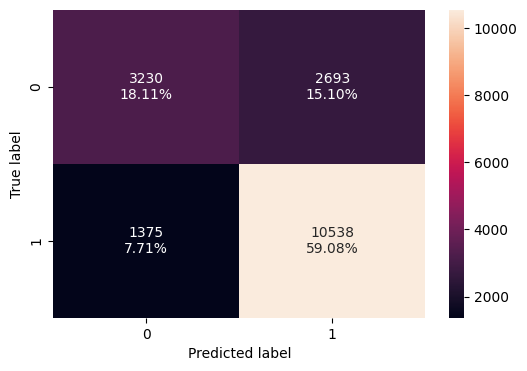

In [ ]:
stacking_classifier_train_performance = model_performance_classification_sklearn(stacking_classifier, X_train, y_train)
print("Training performance: \n", stacking_classifier_train_performance)
print()
confusion_matrix_sklearn(stacking_classifier, X_train, y_train)

#### Testing Set Performance

Testing performance: 
    Accuracy   Recall  Precision        F1
0  0.745814  0.86954   0.776592  0.820442



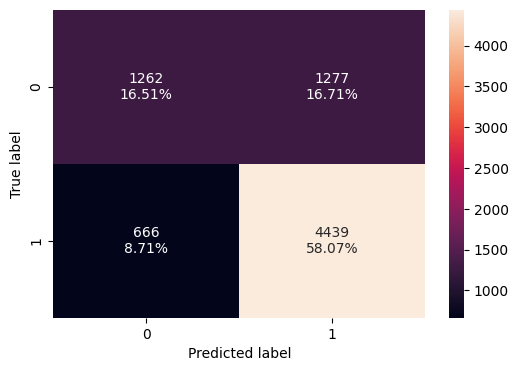

In [ ]:
stacking_classifier_test_performance = model_performance_classification_sklearn(stacking_classifier, X_test, y_test)
print("Testing performance: \n", stacking_classifier_test_performance)
print()
confusion_matrix_sklearn(stacking_classifier, X_test, y_test)

Observations: The model is able to correctly identify the majority of certified applicants, but fails to identify half of the denied applicants.

##  Will tuning the hyperparameters improve the model performance?



*   Decision Tree: Yes, reduced overfitting and improved all metrics except recall.
*   Random Forest Classifier: Yes, slightly reduced overfitting and slightly improved all metrics.
*   Bagging Classifier: Yes, to a lesser degree. Did not reduce overfitting but slightly improved all metrics (especially recall).
*   AdaBoost Classifier: No, minimal improvement after hyperparameter tuning.
*   Gradient Boost Classifier: No, other than a slight increase in recall.
*   XGBoost Classifier: Yes, significantly reduced overfitting and increased metric scores.



## Model Performance Comparison and Conclusions

### Training Performance Comparison

In [ ]:
# training performance comparison
train_comparison = pd.concat(
    [
        tree_train_performance.T,
        tree_estimator_train_performance.T,
        rf_train_performance.T,
        rf_tuned_train_performance.T,
        bc_train_performance.T,
        bc_tuned_train_performance.T,
        ab_classifier_train_performance.T,
        ab_tuned_train_performance.T,
        gb_classifier_train_performance.T,
        gb_tuned_train_performance.T,
        xgb_classifier_train_performance.T,
        xgb_tuned_train_performance.T,
        stacking_classifier_train_performance.T
    ],
    axis=1
)
train_comparison.columns = [
    "Decision Tree",
    "Decision Tree Tuned",
    "Random Forest",
    "Random Forest Tuned",
    "Bagging Classifier",
    "Bagging Classifier Tuned",
    "AdaBoost Classifier",
    "AdaBoost Classifier Tuned",
    "Gradient Boost Classifier",
    "Gradient Boost Classifier Tuned",
    "XGBoost Classifier",
    "XGBoost Classifier Tuned",
    "Stacking Classifier"
]
print("Training Performance Comparison: \n")
train_comparison

Training Performance Comparison: 



,Decision Tree,Decision Tree Tuned,Random Forest,Random Forest Tuned,Bagging Classifier,Bagging Classifier Tuned,AdaBoost Classifier,AdaBoost Classifier Tuned,Gradient Boost Classifier,Gradient Boost Classifier Tuned,XGBoost Classifier,XGBoost Classifier Tuned,Stacking Classifier
Accuracy,1.0,0.710529,1.0,0.915340,0.983797,0.997813,0.738058,0.753869,0.757849,0.753756,0.840884,0.759475,0.771922
Recall,1.0,0.726685,1.0,0.971460,0.984639,0.999748,0.886259,0.887350,0.883657,0.885671,0.930664,0.892470,0.884580
Precision,1.0,0.819481,1.0,0.908185,0.991044,0.996986,0.760937,0.776195,0.782095,0.776894,0.846400,0.779415,0.796463
F1,1.0,0.770299,1.0,0.938757,0.987831,0.998365,0.818830,0.828059,0.829780,0.827724,0.886534,0.832120,0.838212


### Testing Performance Comparison

In [ ]:
# testing performance comparison
test_comparison = pd.concat(
    [
        tree_test_performance.T,
        tree_estimator_test_performance.T,
        rf_test_performance.T,
        rf_tuned_test_performance.T,
        bc_test_performance.T,
        bc_tuned_test_performance.T,
        ab_classifier_test_performance.T,
        ab_tuned_test_performance.T,
        gb_classifier_test_performance.T,
        gb_tuned_test_performance.T,
        xgb_classifier_test_performance.T,
        xgb_tuned_test_performance.T,
        stacking_classifier_test_performance.T
    ],
    axis=1
)
test_comparison.columns = [
    "Decision Tree",
    "Decision Tree Tuned",
    "Random Forest",
    "Random Forest Tuned",
    "Bagging Classifier",
    "Bagging Classifier Tuned",
    "AdaBoost Classifier",
    "AdaBoost Classifier Tuned",
    "Gradient Boost Classifier",
    "Gradient Boost Classifier Tuned",
    "XGBoost Classifier",
    "XGBoost Classifier Tuned",
    "Stacking Classifier"
]
print("Testing Performance Comparison: \n")
test_comparison

Testing Performance Comparison: 



,Decision Tree,Decision Tree Tuned,Random Forest,Random Forest Tuned,Bagging Classifier,Bagging Classifier Tuned,AdaBoost Classifier,AdaBoost Classifier Tuned,Gradient Boost Classifier,Gradient Boost Classifier Tuned,XGBoost Classifier,XGBoost Classifier Tuned,Stacking Classifier
Accuracy,0.660387,0.708399,0.719911,0.734563,0.704212,0.730246,0.734301,0.743851,0.745814,0.745029,0.726583,0.743851,0.745814
Recall,0.739275,0.728110,0.835651,0.860529,0.777081,0.869344,0.883252,0.881881,0.878355,0.881489,0.850735,0.882076,0.869540
Precision,0.748958,0.815489,0.766164,0.769352,0.779371,0.760843,0.758580,0.768653,0.772305,0.770021,0.765826,0.768561,0.776592
F1,0.744085,0.769326,0.799400,0.812390,0.778225,0.811483,0.816182,0.821383,0.821923,0.821993,0.806050,0.821416,0.820442


Observations:
* A little less than half of the models experienced overfitting.
* The best models are the two versions of the Gradient Boost Classifier, followed by the tuned AdaBoost and XGBoost Classifiers.
* The Tuned Gradient Boost Classifier has a slightly highesr f1-score and less overfitting, so it will be used as the final model.

### Feature Importance of Tuned Gradient Boost Classifier

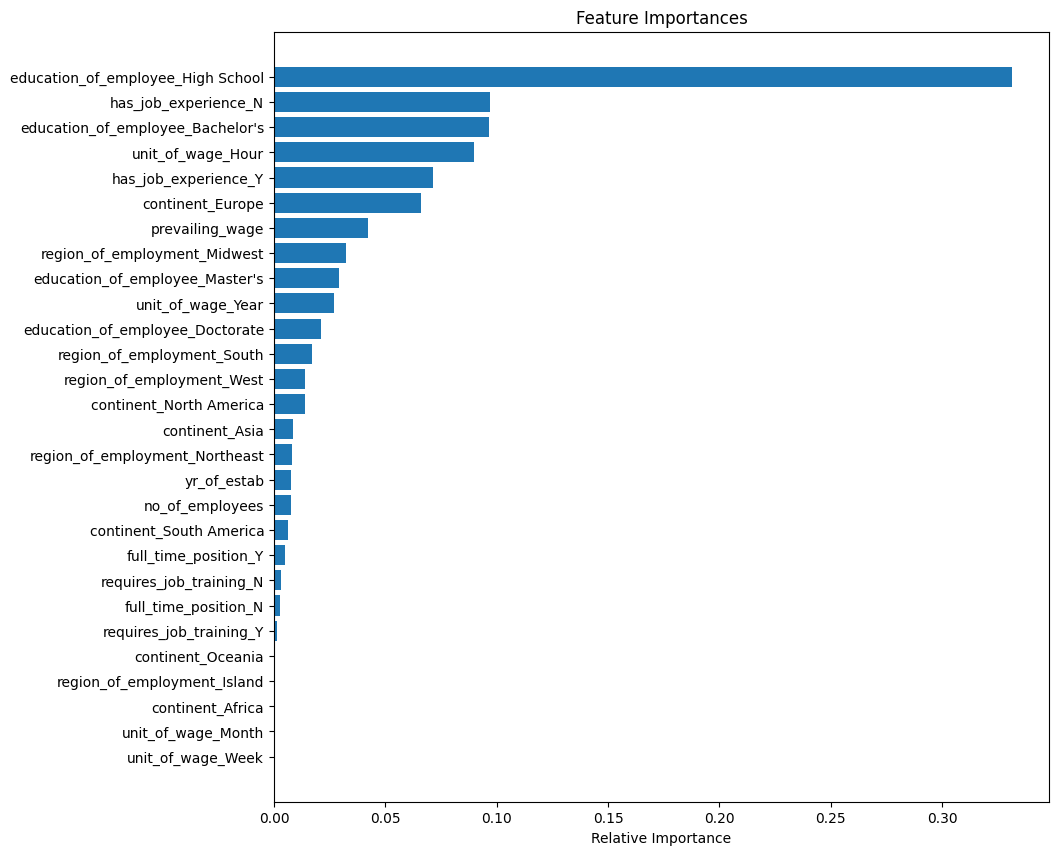

In [ ]:
feature_names = X_train.columns
importances = gb_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10,10))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='#1f77b4', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

Observations: Level of education is the most important feature in determining VISA certification status, with high school being the most impactful. This is followed by minimal job experience.

## Actionable Insights and Recommendations

Based on the analysis, VISA certification status is heavily influenced by:

* Lower education levels - High school/Bachelor degrees have higher denial rates than the other education levels.
* No job experience - Applicants lacking job experience have higher denial rates than those with experience.
* Hourly pay - Applicants with an hourly wage experience higher denial rates.
* European origins - Applicants from Europe have higher certification rates.
* Prevailing wage - Half of the applicants that are accepted have a prevailing wage between 40000 dollars and 100000 dollars.
* Midwest region of employment - The midwest region of the US has the highest VISA certfication rates, possibly due to lower competition and high demand for specialized labor.





Instead of reviewing each and every case, OFLC should filter candidates based on the attributes listed above. Applicants with greater chances of VISA approval (higher education level, job experience, etc.) should be shortlisted for certification. Applicants with low chances (lower education level, no job experience, etc.) should be denied.

Shortlisting applicants based on important factors (education, experience, etc.) would reduce the time and resources needed to review VISA applications every year. By collecting more data, OFLC can also identify other confounding variables to improve the model's predictions.